EDA - Base de datos de accidentes aéreos Aerocivil
Propósito: Identificar tipos de datos, nulos, atípicos y sugerir codificaciones IA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import folium
from folium import plugins
from google.colab import files
from IPython.display import HTML
import glob

In [6]:
# Sincronizar con GIT HUB

from google.colab import drive
drive.mount('/content/drive')

!rm -rf Proyecto-PMN
!git clone https://TU_TOKEN@github.com/jomartinezdi-UNAL/Proyecto-PMN.git

%cd Proyecto-PMN

!cp "/content/drive/MyDrive/Colab Notebooks/"*.ipynb .

!git config --global user.name "Jose Martinez"
!git config --global user.email "jomartinezdi@unal.edu.co"

!git add .
!git commit -m "Update desde Colab"
!git push

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'Proyecto-PMN'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 33 (delta 4), reused 21 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 423.02 KiB | 6.13 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/Proyecto-PMN/Proyecto-PMN
[main c1a7c16] Update desde Colab
 11 files changed, 11 insertions(+)
 create mode 100644 FFE_Linealizacion.ipynb
 create mode 100644 FFT Analisis_acc.ipynb
 create mode 100644 MME Burbuja aire.ipynb
 create mode 100644 "MME Generacio\314\201n Datos.ipynb"
 create mode 100644 PMN - EDA Proyecto.ipynb
 create mode 100644 PMN Clases temas.ipynb
 create mode 100644 PMN Codeabbey.ipynb
 create mode 100644 PMN Secuencias de Plots.ipynb
 create mode 100644 PUJ Procesamiento de datos.ipynb
 create mod

In [ ]:
# Configurar visualización
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

print("="*80)
print("ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("Base de datos de accidentes aéreos - Aerocivil")
print("="*80)

ANÁLISIS EXPLORATORIO DE DATOS (EDA)
Base de datos de accidentes aéreos - Aerocivil


In [ ]:
# ============================================================================
# 1. CARGA DE DATOS
# ============================================================================

try:
    df = pd.read_csv('accidentes_aereos.csv', encoding='latin1', low_memory=False)
    print("✓ Archivo cargado exitosamente")
except FileNotFoundError:
    print("! Archivo no encontrado. Creando estructura de ejemplo...")
    print("  Reemplaza esta sección con: df = pd.read_csv('tu_archivo.csv')")

    # Crear datos de ejemplo para demostración
    np.random.seed(42)
    n_muestras = 1000

    # Fechas aleatorias (últimos 15 años)
    fechas = pd.date_range('2010-01-01', '2024-12-31', periods=n_muestras)

    df = pd.DataFrame({
        'Fecha': fechas,
        'Departamento': np.random.choice(['Antioquia', 'Cundinamarca', 'Valle', 'Bolívar', 'Santander'], n_muestras),
        'Municipio': np.random.choice(['Medellín', 'Bogotá', 'Cali', 'Cartagena', 'Bucaramanga'], n_muestras),
        'Fase de vuelo': np.random.choice(['Despegue', 'Crucero', 'Aterrizaje', 'Taxeo', 'Maniobras'], n_muestras),
        'Misión del vuelo': np.random.choice(['Privado', 'Comercial', 'Entrenamiento', 'Aeronavegación'], n_muestras),
        'Total fatales': np.random.poisson(0.5, n_muestras),
        'Total graves': np.random.poisson(0.3, n_muestras),
        'Total leves': np.random.poisson(0.8, n_muestras),
        'Total ilesos': np.random.poisson(2, n_muestras),
        'Porcentaje de superviviencia': np.random.uniform(0, 100, n_muestras),
        'Causa probable': np.random.choice(['Pérdida de control', 'Falla de motor', 'Error humano',
                                              'Condiciones climáticas', 'Choque con ave'], n_muestras),
        'Fabricante': np.random.choice(['Cessna', 'Piper', 'Beechcraft', 'Airbus', 'Boeing'], n_muestras),
        'Año de fabricación': np.random.randint(1970, 2020, n_muestras),
        'No. Tripulantes': np.random.randint(1, 6, n_muestras),
        'No. Pasajeros': np.random.randint(0, 50, n_muestras),
    })

    # Agregar algunos nulos intencionales
    for col in ['Total fatales', 'Causa probable', 'Fabricante']:
        idx_nulos = np.random.choice(df.index, size=int(0.05*n_muestras), replace=False)
        df.loc[idx_nulos, col] = np.nan

    # Agregar algunos valores atípicos
    df.loc[np.random.choice(df.index, 5), 'Total fatales'] = np.random.randint(50, 100, 5)
    df.loc[np.random.choice(df.index, 3), 'Porcentaje de superviviencia'] = np.random.uniform(200, 500, 3)

print(f"✓ Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")

✓ Archivo cargado exitosamente
✓ Dimensiones: 112 filas, 177 columnas


In [ ]:
# ============================================================================
# 2. INFORMACIÓN GENERAL DEL DATAFRAME
# ============================================================================
print("\n2. INFORMACIÓN GENERAL DEL DATAFRAME")
print("-"*50)
print("\nPrimeras 15 filas:")
print(df.head(15))
print("\nInformación de columnas:")
print(df.info())


2. INFORMACIÓN GENERAL DEL DATAFRAME
--------------------------------------------------

Primeras 15 filas:
   Código investigación       Clasificación Matrícula     Fecha Fecha UTC   Hora Hora UTC Condiciones de luz    Estado Sigla estado     Departamento  Cod.D             Municipio   Cod.M      Localización frente a ad. Aeródromo  LAG  LAM    LAS LASIG  LOG  LOM    LOS LOSIG    LAT GMS   LONG GMS LAG° LAM' LAS'' LASIG LOG° LOM' LOS'' LOSIG  LAT ECCAIRS  LONG ECCAIRS  Detalle lugar de la posición final de la aeronave         Nit               Explotador                                       Razón Social                      ActAerea                           ActAerea1                                  Título del evento                                 Resumen del evento Ad. de Origen Detalle origen Ad. de destino Detalle destino                    Misión del vuelo    Fase de vuelo  Momento del vuelo Posición        Tipo de descenso  Punto de aterrizaje                  Tipo del terren

In [ ]:
# ============================================================================
# 3. ANÁLISIS DE TIPOS DE DATOS
# ============================================================================
print("\n3. ANÁLISIS DE TIPOS DE DATOS")
print("-"*50)

tipos_datos = pd.DataFrame({
    'Tipo_dato': df.dtypes,
    'Es_numérico': df.dtypes.apply(lambda x: pd.api.types.is_numeric_dtype(x)),
    'Es_categórico': df.dtypes.apply(lambda x: pd.api.types.is_object_dtype(x) or pd.api.types.is_categorical_dtype(x)),
    'Es_fecha': df.dtypes.apply(lambda x: pd.api.types.is_datetime64_any_dtype(x)),
    'N_unique': df.nunique()
})

print("\nResumen por tipo de dato:")
print(tipos_datos.groupby('Tipo_dato').size())
print("\nDetalle por columna (todas):")
print(tipos_datos)

# Identificar columnas numéricas y categóricas
columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
columnas_fecha = df.select_dtypes(include=['datetime64']).columns.tolist()

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(f"\n✓ Columnas numéricas ({len(columnas_numericas)}): {columnas_numericas[:10]}...")
print(f"✓ Columnas categóricas ({len(columnas_categoricas)}): {columnas_categoricas[:10]}...")
print(f"✓ Columnas fecha ({len(columnas_fecha)}): {columnas_fecha}")


3. ANÁLISIS DE TIPOS DE DATOS
--------------------------------------------------

Resumen por tipo de dato:
Tipo_dato
int64       23
float64     38
object     116
dtype: int64

Detalle por columna (todas):
                                                  Tipo_dato  Es_numérico  Es_categórico  Es_fecha  N_unique
Código investigación                                 object        False           True     False       112
Clasificación                                        object        False           True     False         2
Matrícula                                            object        False           True     False       105
Fecha                                                object        False           True     False       110
Fecha UTC                                            object        False           True     False       110
Hora                                                 object        False           True     False        96
Hora UTC                             


4. ANÁLISIS DE DATOS NULOS
--------------------------------------------------

Top 80 columnas con más nulos:
                                Nulos  Porcentaje
CONCATENADO                       112  100.000000
FACTORES INVOLUCRADOS             112  100.000000
Cantidad de recomendaciones       110   98.214286
Tipo de tren                      107   95.535714
Tipo de tren de aterrizaje        107   95.535714
ATS                               106   94.642857
Aeródromo.1                       106   94.642857
Detalle punto de aterrizaje       106   94.642857
Detalle del incendio              105   93.750000
Obstaculos                        105   93.750000
Detalle componente                105   93.750000
Tipo del terreno                  103   91.964286
Detalle destino                   103   91.964286
Alerta                            103   91.964286
Componente que falla              102   91.071429
Detalle origen                     99   88.392857
Mantenimiento                      98  

<Figure size 2000x1000 with 0 Axes>

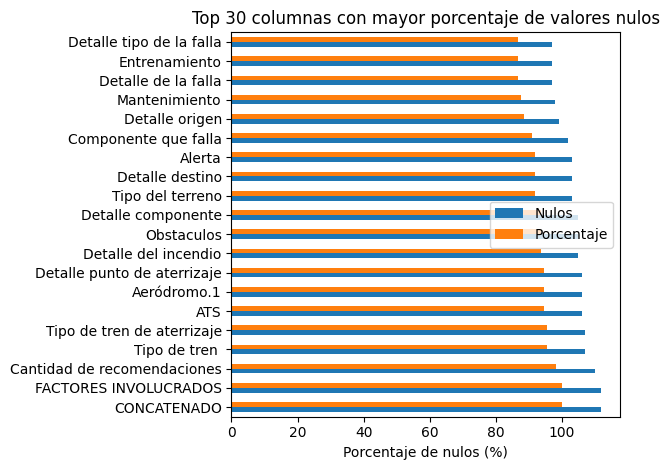

In [ ]:
# ============================================================================
# 4. ANÁLISIS DE DATOS NULOS
# ============================================================================
print("\n4. ANÁLISIS DE DATOS NULOS")
print("-"*50)

nulos = df.isnull().sum()
nulos_porcentaje = (nulos / len(df)) * 100
nulos_df = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje': nulos_porcentaje
}).sort_values('Nulos', ascending=False)

print("\nTop 80 columnas con más nulos:")
print(nulos_df.head(80))

# Clasificar columnas según su nivel de nulos
columnas_buenas = nulos_df[nulos_df['Porcentaje'] < 5].index.tolist()
columnas_medias = nulos_df[(nulos_df['Porcentaje'] >= 5) & (nulos_df['Porcentaje'] < 30)].index.tolist()
columnas_malas = nulos_df[nulos_df['Porcentaje'] >= 30].index.tolist()

print(f"\n✓ Columnas con <5% nulos (buenas): {len(columnas_buenas)}")
print(f"✓ Columnas con 5-30% nulos (medias): {len(columnas_medias)}")
print(f"✓ Columnas con >30% nulos (malas): {len(columnas_malas)}")

# Visualización de nulos
plt.figure(figsize=(20, 10))
nulos_df.head(20).plot(kind='barh')
plt.title('Top 30 columnas con mayor porcentaje de valores nulos')
plt.xlabel('Porcentaje de nulos (%)')
plt.tight_layout()
plt.savefig('nulos_por_columna.png', dpi=300)
print("\n✓ Gráfico guardado: nulos_por_columna.png")

In [ ]:
# ============================================================================
# 5. ESTADÍSTICAS PARA DATOS NUMÉRICOS
# ============================================================================
print("\n5. ESTADÍSTICAS DESCRIPTIVAS - DATOS NUMÉRICOS")
print("-"*50)

if len(columnas_numericas) > 0:
    estadisticas_numericas = df[columnas_numericas].describe()
    print("\nEstadísticas generales:")
    print(estadisticas_numericas)

    # Promedios específicos
    print("\n✓ Promedios por columna:")
    promedios = df[columnas_numericas].mean()
    for col in columnas_numericas[:10]:
        print(f"  - {col}: {promedios[col]:.2f}")

    # Guardar estadísticas completas
    estadisticas_numericas.to_csv('estadisticas_numericas.csv')
    print("\n✓ Estadísticas guardadas en: estadisticas_numericas.csv")
else:
    print("No hay columnas numéricas en el dataset")


5. ESTADÍSTICAS DESCRIPTIVAS - DATOS NUMÉRICOS
--------------------------------------------------

Estadísticas generales:
            Cod.D       Cod.M         LAG         LAM         LAS         LOG         LOM         LOS     LAT GMS    LONG GMS   LAT ECCAIRS  LONG ECCAIRS  Momento del vuelo  No. Tripulantes  No. Pasajeros  Total Abordo  Fatales tripulación  Graves tripulación  Leves tripulación  Ilesos tripulación  Fatales pasajeros  Graves pasajeros  Leves pasajeros  Ilesos pasajeros  Fatales otros  Graves otros  Leves otros  Total fatales  Total graves  Total leves  Total ilesos        Edad  Días desde último chequeo  Horas De Vuelo  Horas De Equipo  Horas Ultimos 90 Dias  Horas Ultimos 30 Dias  Horas Ultimos 03 Dias     Edad.1  Días desde último chequeo.1  Horas De Vuelo.1  Horas De Equipo.1  Horas Ultimos 90 Dias.1  Horas Ultimos 30 Dias.1  Horas Ultimos 03 Dias.1  Año de fabricación  No. Pasajeros.1  No. Tripulación   PesoVacioKG         PMBOkg    #Motores  A - Horas totales 


6. DETECCIÓN DE VALORES ATÍPICOS
--------------------------------------------------

  LAG:
    - Outliers detectados: 12 (10.71%)
    - Rango normal: [1.00, 9.00]

  LOG:
    - Outliers detectados: 3 (2.68%)
    - Rango normal: [67.50, 79.50]

  LAT GMS:
    - Outliers detectados: 14 (12.50%)
    - Rango normal: [1.18, 9.19]

  LONG GMS:
    - Outliers detectados: 3 (2.68%)
    - Rango normal: [-79.02, -68.74]

✓ Boxplots guardados en: boxplots_outliers.png


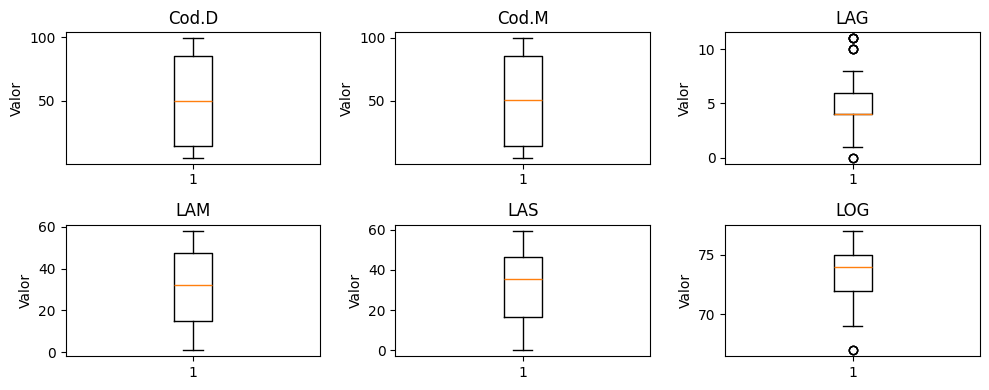

In [ ]:
# ============================================================================
# 6. DETECCIÓN DE VALORES ATÍPICOS (OUTLIERS)
# ============================================================================
print("\n6. DETECCIÓN DE VALORES ATÍPICOS")
print("-"*50)

outliers_dict = {}
for col in columnas_numericas[:10]:  # Limitados a 10
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    n_outliers = len(outliers)
    porcentaje_outliers = (n_outliers / len(df)) * 100

    if n_outliers > 0:
        outliers_dict[col] = {
            'n_outliers': n_outliers,
            'porcentaje': porcentaje_outliers,
            'limite_inferior': limite_inferior,
            'limite_superior': limite_superior
        }
        print(f"\n  {col}:")
        print(f"    - Outliers detectados: {n_outliers} ({porcentaje_outliers:.2f}%)")
        print(f"    - Rango normal: [{limite_inferior:.2f}, {limite_superior:.2f}]")

# Visualización con boxplots
if len(columnas_numericas) > 0:
    n_cols = min(len(columnas_numericas), 6)
    fig, axes = plt.subplots(2, 3, figsize=(10, 4))
    axes = axes.flatten()
    for i, col in enumerate(columnas_numericas[:6]):
        axes[i].boxplot(df[col].dropna())
        axes[i].set_title(col)
        axes[i].set_ylabel('Valor')
    plt.tight_layout()
    plt.savefig('boxplots_outliers.png', dpi=100)
    print("\n✓ Boxplots guardados en: boxplots_outliers.png")

In [ ]:
# ============================================================================
# 7. ANÁLISIS DE DATOS CATEGÓRICOS Y PROPUESTA DE CODIFICACIÓN
# ============================================================================
print("\n7. ANÁLISIS DE DATOS CATEGÓRICOS Y CODIFICACIÓN")
print("-"*50)

propuesta_codificacion = []

for col in columnas_categoricas[:15]:  # Limitados a 15
    valores_unicos = df[col].dropna().unique()
    n_categorias = len(valores_unicos)
    frecuencias = df[col].value_counts()
    categoria_mas_frecuente = frecuencias.index[0] if len(frecuencias) > 0 else None
    frecuencia_mas_alta = frecuencias.iloc[0] if len(frecuencias) > 0 else 0

    # Proponer método de codificación según número de categorías
    if n_categorias <= 2:
        metodo = "Codificación binaria (0/1)"
        ejemplo = f"'{categoria_mas_frecuente}' → 1, otros → 0"
    elif n_categorias <= 10:
        metodo = "One-Hot Encoding (crear columnas binarias por categoría)"
        ejemplo = f"Se crearían {n_categorias} columnas"
    elif n_categorias <= 50:
        metodo = "Codificación ordinal (si hay orden natural) o frecuencia"
        ejemplo = f"Asignar orden según frecuencia: {list(frecuencias.head(3).index)}"
    else:
        metodo = "Codificación por frecuencia o target encoding (con precaución)"
        ejemplo = f"Demasiadas categorías ({n_categorias}) → agrupar las menos frecuentes en 'Otros'"

    propuesta_codificacion.append({
        'Columna': col,
        'N_categorías': n_categorias,
        'Categoría_más_frecuente': categoria_mas_frecuente,
        'Frecuencia': frecuencia_mas_alta,
        'Método_sugerido': metodo,
        'Ejemplo': ejemplo
    })

    print(f"\n  {col}:")
    print(f"    - Categorías únicas: {n_categorias}")
    print(f"    - Más común: '{categoria_mas_frecuente}' ({frecuencia_mas_alta} ocurrencias)")
    print(f"    - Método sugerido: {metodo}")
    print(f"    - Ejemplo: {ejemplo}")

# Guardar propuesta de codificación
df_codificacion = pd.DataFrame(propuesta_codificacion)
df_codificacion.to_csv('propuesta_codificacion_categorias.csv', index=False)
print("\n✓ Propuesta de codificación guardada en: propuesta_codificacion_categorias.csv")


7. ANÁLISIS DE DATOS CATEGÓRICOS Y CODIFICACIÓN
--------------------------------------------------

  Código investigación:
    - Categorías únicas: 112
    - Más común: 'COL-23-22-DIACC' (1 ocurrencias)
    - Método sugerido: Codificación por frecuencia o target encoding (con precaución)
    - Ejemplo: Demasiadas categorías (112) → agrupar las menos frecuentes en 'Otros'

  Clasificación:
    - Categorías únicas: 2
    - Más común: '1. Accidente' (63 ocurrencias)
    - Método sugerido: Codificación binaria (0/1)
    - Ejemplo: '1. Accidente' → 1, otros → 0

  Matrícula:
    - Categorías únicas: 105
    - Más común: 'HK1635' (2 ocurrencias)
    - Método sugerido: Codificación por frecuencia o target encoding (con precaución)
    - Ejemplo: Demasiadas categorías (105) → agrupar las menos frecuentes en 'Otros'

  Fecha:
    - Categorías únicas: 110
    - Más común: '12-04-15' (2 ocurrencias)
    - Método sugerido: Codificación por frecuencia o target encoding (con precaución)
    - Ejem


8. MATRIZ DE CORRELACIONES
--------------------------------------------------

Correlaciones fuertes encontradas (|r| > 0.5):
  Cod.D ↔ Cantidad de recomendaciones: -1.000
  Cod.M ↔ Cantidad de recomendaciones: -1.000
  LAG ↔ Cantidad de recomendaciones: -1.000
  LAS ↔ Cantidad de recomendaciones: -1.000
  LOG ↔ Cantidad de recomendaciones: 1.000
  LOM ↔ Cantidad de recomendaciones: 1.000
  LOS ↔ Cantidad de recomendaciones: -1.000
  LAT GMS ↔ Cantidad de recomendaciones: -1.000
  LAT ECCAIRS ↔ Cantidad de recomendaciones: -1.000
  LONG ECCAIRS ↔ Cantidad de recomendaciones: -1.000
  No. Tripulantes ↔ Cantidad de recomendaciones: 1.000
  No. Pasajeros ↔ Cantidad de recomendaciones: 1.000
  Total Abordo ↔ Cantidad de recomendaciones: 1.000
  Fatales tripulación ↔ Cantidad de recomendaciones: -1.000
  Ilesos tripulación ↔ Cantidad de recomendaciones: 1.000
  Ilesos pasajeros ↔ Cantidad de recomendaciones: 1.000
  Total fatales ↔ Cantidad de recomendaciones: -1.000
  Total ilesos ↔ Canti

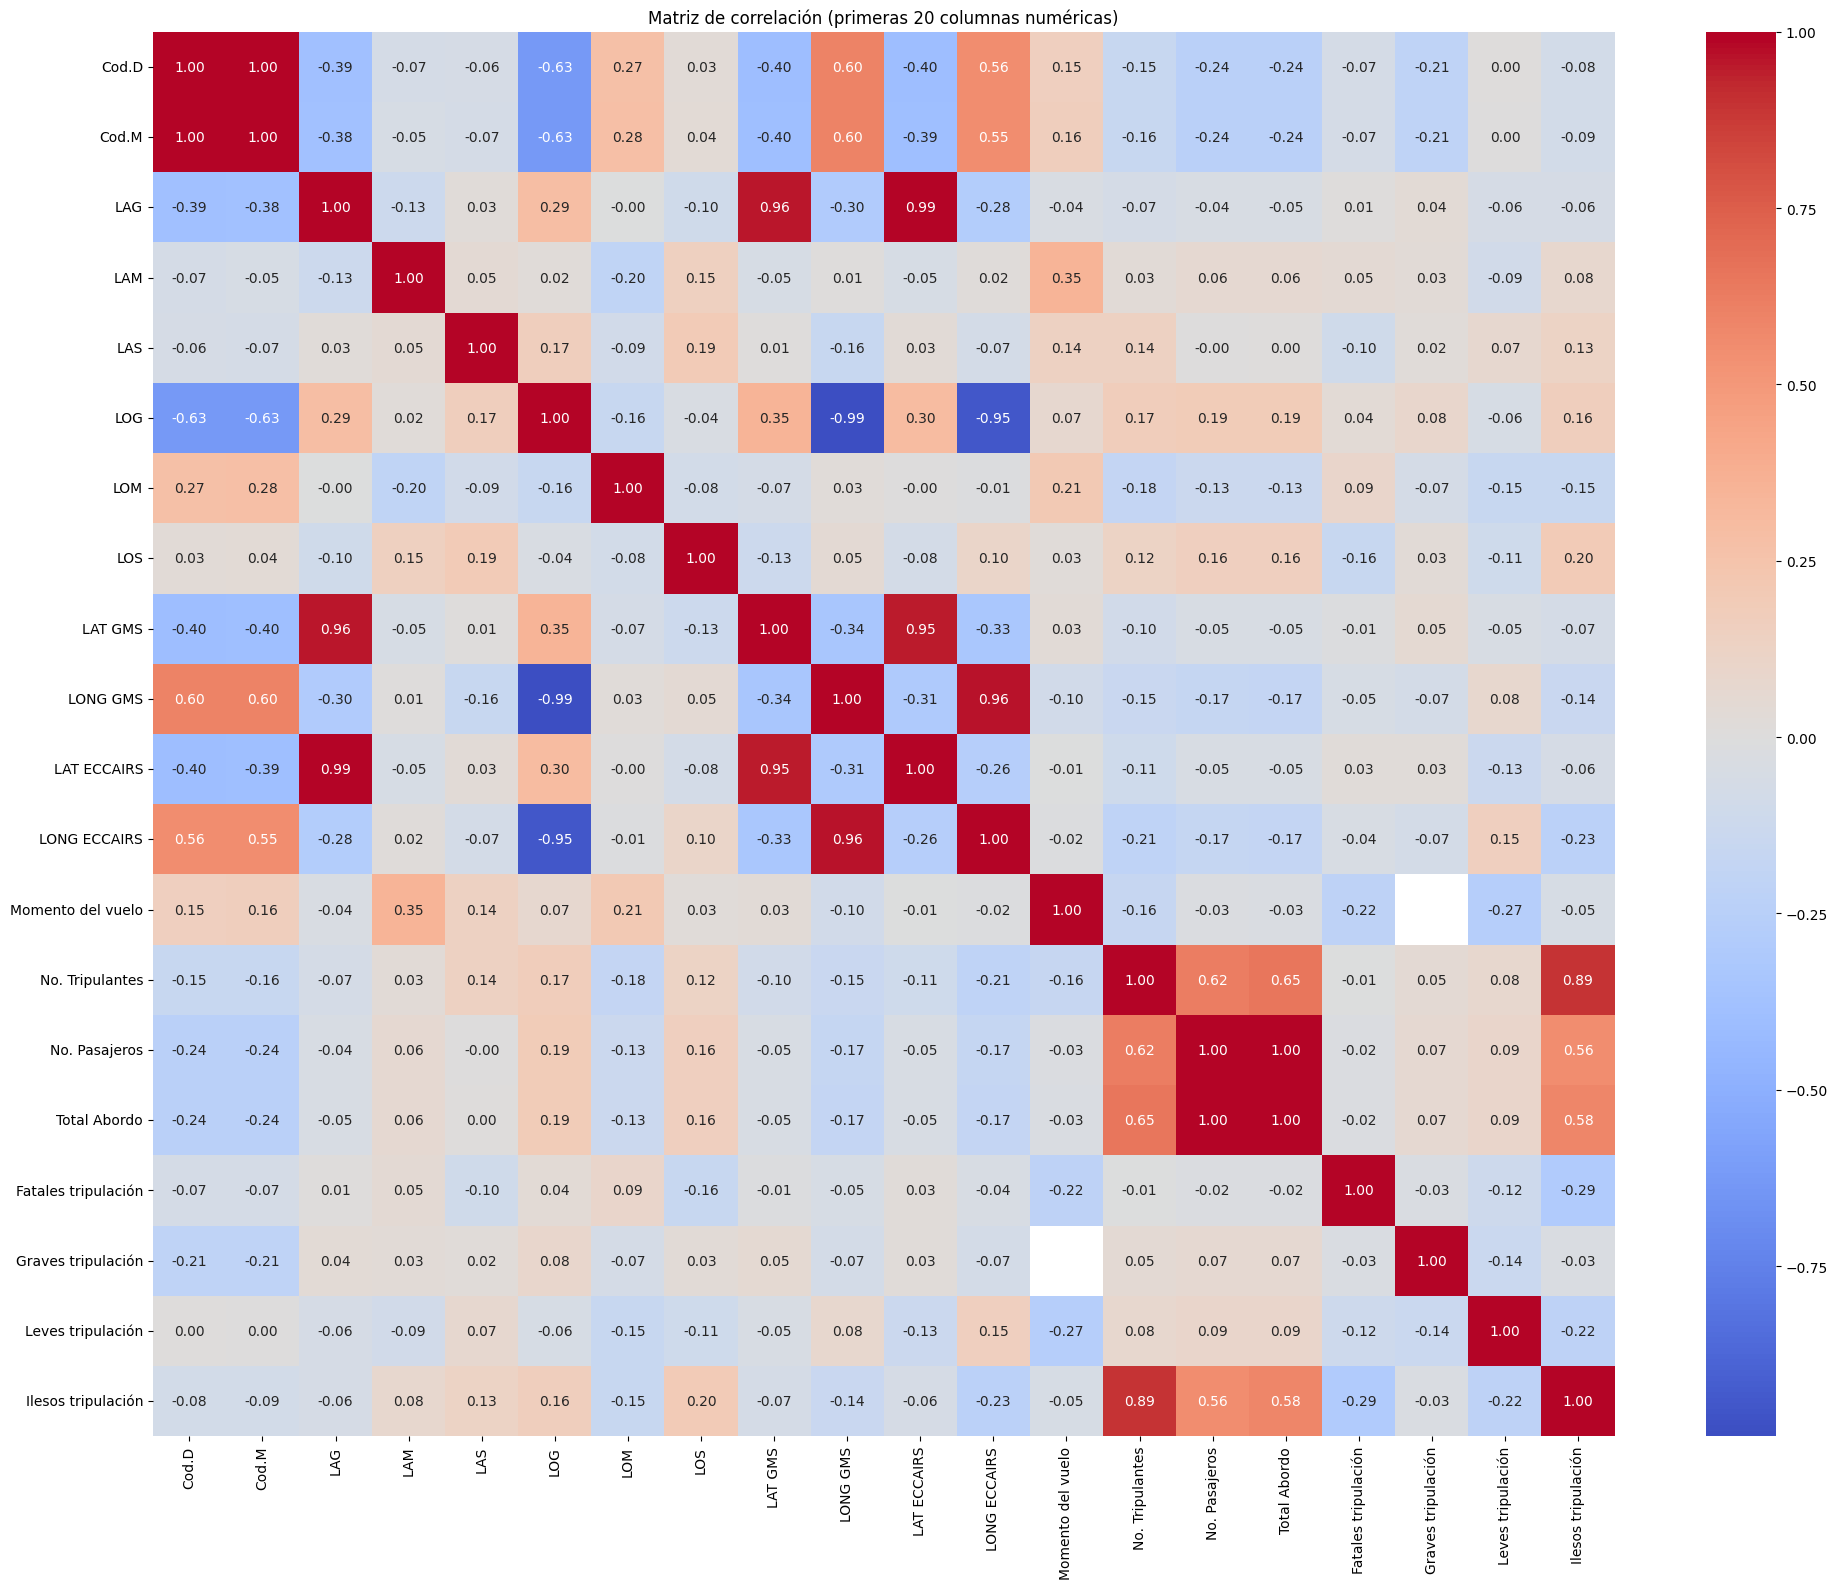

In [ ]:
# ============================================================================
# 8. CORRELACIONES ENTRE VARIABLES NUMÉRICAS
# ============================================================================
if len(columnas_numericas) >= 2:
    print("\n8. MATRIZ DE CORRELACIONES")
    print("-"*50)

    # Calcular correlaciones
    correlaciones = df[columnas_numericas].corr()

    # Mostrar correlaciones más fuertes (|r| > 0.5)
    correlaciones_fuertes = []
    for i in range(len(correlaciones.columns)):
        for j in range(i+1, len(correlaciones.columns)):
            r = correlaciones.iloc[i, j]
            if abs(r) > 0.5 and not np.isnan(r):
                correlaciones_fuertes.append({
                    'Variable_1': correlaciones.columns[i],
                    'Variable_2': correlaciones.columns[j],
                    'Correlación': r
                })

    if correlaciones_fuertes:
        print("\nCorrelaciones fuertes encontradas (|r| > 0.5):")
        for corr in sorted(correlaciones_fuertes, key=lambda x: abs(x['Correlación']), reverse=True):
            print(f"  {corr['Variable_1']} ↔ {corr['Variable_2']}: {corr['Correlación']:.3f}")
    else:
        print("No se encontraron correlaciones fuertes entre variables numéricas")

    # Visualizar matriz de correlación (primeras 20 columnas)
    n_corr = min(len(columnas_numericas), 20)
    plt.figure(figsize=(20, 16))
    sns.heatmap(correlaciones.iloc[:n_corr, :n_corr], annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title(f'Matriz de correlación (primeras {n_corr} columnas numéricas)')
    plt.tight_layout()
    plt.savefig('matriz_correlacion.png', dpi=100)
    print("\n✓ Matriz de correlación guardada en: matriz_correlacion.png")

In [ ]:
# ============================================================================
# 9. ANÁLISIS DE VARIABLES FECHA
# ============================================================================
if len(columnas_fecha) > 0:
    print("\n9. ANÁLISIS DE VARIABLES FECHA")
    print("-"*50)

    for col in columnas_fecha:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            print(f"\n  {col}:")
            print(f"    - Rango: {df[col].min()} a {df[col].max()}")
            print(f"    - Años disponibles: {df[col].dt.year.unique()[:10]}...")

            # Extraer componentes útiles para análisis numérico
            print(f"    - Componentes extraíbles: año, mes, día, día_semana, trimestre")

            # Propuesta de codificación numérica
            print(f"    - Propuesta: convertir a número de días desde época o usar año numérico")

In [ ]:
# ============================================================================
# 10. RESUMEN EJECUTIVO Y RECOMENDACIONES
# ============================================================================
print("\n" + "="*80)
print("10. RESUMEN EJECUTIVO Y RECOMENDACIONES")
print("="*80)

print("""
HALLAZGOS PRINCIPALES:
----------------------------------------""")

print(f"1. Dimensión del dataset: {df.shape[0]} registros, {df.shape[1]} columnas")
print(f"2. Tipos de datos: {len(columnas_numericas)} numéricas, {len(columnas_categoricas)} categóricas, {len(columnas_fecha)} fechas")
print(f"3. Calidad de datos: {len(columnas_buenas)} columnas con <5% nulos, {len(columnas_malas)} columnas con >30% nulos")
print(f"4. Outliers detectados en {len(outliers_dict)} columnas numéricas")

print("""
RECOMENDACIONES PARA EL PROYECTO:
----------------------------------------""")

print("""
A. MANEJO DE DATOS NULOS:
   - Columnas con <5% nulos: eliminar filas con nulos o imputar con moda/media
   - Columnas con 5-30% nulos: imputación estratégica (media, mediana, moda según contexto)
   - Columnas con >30% nulos: evaluar si son realmente necesarias para el análisis

B. CODIFICACIÓN DE VARIABLES CATEGÓRICAS (para análisis estadístico):
   - Variables binarias (2 categorías): codificar como 0/1
   - Variables nominales (3-10 categorías): usar One-Hot Encoding
   - Variables ordinales (con orden natural): asignar valores 1,2,3...
   - Variables con muchas categorías: agrupar las menos frecuentes en "Otros"

C. TRATAMIENTO DE OUTLIERS:
   - Investigar si los outliers son errores de datos o eventos reales (ej: accidente con 80 fatales)
   - Para estadísticas robustas: usar mediana en lugar de media
   - Para visualización: usar escalas logarítmicas o boxplots

D. VARIABLES ESPECÍFICAS PARA MÉTODOS NUMÉRICOS (según contenido del curso):
   - Interpolación: usar año y número de accidentes por año
   - Integración: área bajo curva de tendencia de accidentalidad
   - Diferencias finitas: tasa de cambio anual
   - Promedios y desviaciones: Total fatales, Porcentaje de supervivencia
   - Nube de palabras: usar Causa probable o Resumen del evento (conteo de frecuencias)
""")

# Guardar resumen completo
with open('eda_resumen_completo.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("EDA - BASE DE DATOS ACCIDENTES AÉREOS\n")
    f.write("="*80 + "\n\n")
    f.write(f"Dimensiones: {df.shape}\n\n")
    f.write("Columnas numéricas:\n")
    f.write(str(columnas_numericas) + "\n\n")
    f.write("Columnas categóricas:\n")
    f.write(str(columnas_categoricas) + "\n\n")
    f.write("Resumen nulos:\n")
    f.write(nulos_df.to_string() + "\n\n")
    f.write("Propuesta codificación:\n")
    f.write(df_codificacion.to_string())

print("\n✓ Resumen completo guardado en: eda_resumen_completo.txt")
print("\n" + "="*80)
print("EDA COMPLETADO EXITOSAMENTE")
print("="*80)


10. RESUMEN EJECUTIVO Y RECOMENDACIONES

HALLAZGOS PRINCIPALES:
----------------------------------------
1. Dimensión del dataset: 112 registros, 177 columnas
2. Tipos de datos: 61 numéricas, 116 categóricas, 0 fechas
3. Calidad de datos: 88 columnas con <5% nulos, 63 columnas con >30% nulos
4. Outliers detectados en 4 columnas numéricas

RECOMENDACIONES PARA EL PROYECTO:
----------------------------------------

A. MANEJO DE DATOS NULOS:
   - Columnas con <5% nulos: eliminar filas con nulos o imputar con moda/media
   - Columnas con 5-30% nulos: imputación estratégica (media, mediana, moda según contexto)
   - Columnas con >30% nulos: evaluar si son realmente necesarias para el análisis

B. CODIFICACIÓN DE VARIABLES CATEGÓRICAS (para análisis estadístico):
   - Variables binarias (2 categorías): codificar como 0/1
   - Variables nominales (3-10 categorías): usar One-Hot Encoding
   - Variables ordinales (con orden natural): asignar valores 1,2,3...
   - Variables con muchas categoría

In [ ]:
# ============================================================================
# 11. ELIMINAR COLUMNAS ESPECIFICADAS
# ============================================================================

# 1. Columnas que indicaste manualmente
columnas_manuales = [
    'Código investigación',
    'Matrícula',
    'Fecha UTC',
    'Hora',
    'Estado',
    'Sigla estado',
    'Cod.D',
    'Cod.M',
    'LAG',
    'LAM',
    'LAS',
    'LASIG',
    'LOG',
    'LOM',
    'LOS',
    'LOSIG',
    "LAG° LAM' LAS'' LASIG",
    "LOG° LOM' LOS'' LOSIG",
    'LAT ECCAIRS',
    'LONG ECCAIRS',
    'Nit',
    'Razón Social',
    'Fabricante',
    'Modelo 2',
    'Serial',
    'Modelo motores',
    'Consejo',
    'Días abierta',
    'Fecha finalización',
    'Días de finalización',
    'Dias sin publicar',
    'Fecha de publicación',
    'Días de publicación'
]

# 2. Columnas con alto % de nulos (de tu lista)
columnas_nulos = [
    'CONCATENADO',
    'FACTORES INVOLUCRADOS',
    'Cantidad de recomendaciones',
    'Tipo de tren ',
    'Tipo de tren de aterrizaje',
    'ATS',
    'Aeródromo.1',
    'Detalle punto de aterrizaje',
    'Detalle del incendio',
    'Obstaculos',
    'Detalle componente',
    'Tipo del terreno',
    'Detalle destino',
    'Alerta',
    'Componente que falla',
    'Detalle origen',
    'Mantenimiento',
    'Detalle de la falla',
    'Entrenamiento',
    'Detalle tipo de la falla',
    'Detalle de obstáculo',
    'Taxonomía Agravante',
    'Tipo de la falla',
    'Posición del componente',
    'Parte de avión',
    'Otros daños',
    'Organizativo',
    'Momento del vuelo',
    'Tipo de mantenimiento',
    'Ambiental',
    'Taxonomía Consecuente'
]

# Unir ambas listas y eliminar duplicados
columnas_a_eliminar = list(set(columnas_manuales + columnas_nulos))

# Ver cuántas existen realmente en tu DataFrame
columnas_existentes = [col for col in columnas_a_eliminar if col in df.columns]
columnas_faltantes = [col for col in columnas_a_eliminar if col not in df.columns]

print("="*80)
print("ELIMINACIÓN DE COLUMNAS")
print("="*80)
print(f"\nColumnas a eliminar (total): {len(columnas_a_eliminar)}")
print(f"✓ Columnas existentes en el DataFrame: {len(columnas_existentes)}")
print(f"✗ Columnas no encontradas (ignoradas): {len(columnas_faltantes)}")

# Mostrar las columnas no encontradas
if columnas_faltantes:
    print("\nColumnas no encontradas:")
    for col in columnas_faltantes:
        print(f"  • {col}")

# Eliminar las columnas
df_limpio = df.drop(columns=columnas_existentes, errors='ignore')

print(f"\n✓ Dimensiones originales: {df.shape[1]} columnas")
print(f"✓ Columnas eliminadas: {len(columnas_existentes)}")
print(f"✓ Dimensiones finales: {df_limpio.shape[1]} columnas")

# Mostrar las columnas que quedaron (primeras 20)
print("\nPrimeras 20 columnas del DataFrame limpio:")
for i, col in enumerate(df_limpio.columns[:20]):
    print(f"  {i+1}. {col}")

ELIMINACIÓN DE COLUMNAS

Columnas a eliminar (total): 64
✓ Columnas existentes en el DataFrame: 64
✗ Columnas no encontradas (ignoradas): 0

✓ Dimensiones originales: 177 columnas
✓ Columnas eliminadas: 64
✓ Dimensiones finales: 113 columnas

Primeras 20 columnas del DataFrame limpio:
  1. Clasificación
  2. Fecha
  3. Hora UTC
  4. Condiciones de luz
  5. Departamento
  6. Municipio
  7. Localización frente a ad.
  8. Aeródromo
  9. LAT GMS
  10. LONG GMS
  11. Detalle lugar de la posición final de la aeronave
  12. Explotador
  13. ActAerea
  14. ActAerea1
  15. Título del evento
  16. Resumen del evento
  17. Ad. de Origen
  18. Ad. de destino
  19. Misión del vuelo
  20. Fase de vuelo


In [ ]:
# ============================================================================
# 12. GUARDAR Y DESCARGAR CSV LIMPIO
# ============================================================================

print("="*80)
print("GENERANDO CSV CON COLUMNAS ELIMINADAS")
print("="*80)

# Nombre del archivo de salida
nombre_archivo = 'accidentes_aereos_limpio.csv'

# Guardar el DataFrame limpio como CSV
df_limpio.to_csv(nombre_archivo, index=False, encoding='utf-8-sig')

print(f"\n✓ Archivo guardado: {nombre_archivo}")
print(f"✓ Dimensiones del archivo: {df_limpio.shape[0]} filas, {df_limpio.shape[1]} columnas")
print(f"✓ Tamaño aproximado: {df_limpio.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

# ============================================================================
# DESCARGAR EN GOOGLE COLAB
# ============================================================================

from google.colab import files
files.download(nombre_archivo)

print(f"\n✓ Descarga iniciada: {nombre_archivo}")

GENERANDO CSV CON COLUMNAS ELIMINADAS

✓ Archivo guardado: accidentes_aereos_limpio.csv
✓ Dimensiones del archivo: 112 filas, 113 columnas
✓ Tamaño aproximado: 0.70 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Descarga iniciada: accidentes_aereos_limpio.csv


In [ ]:
# ============================================================================
# 13 - GENERACIÓN DE GRÁFICAS DE BARRAS (ACCIDENTES VS INCIDENTES)
# ============================================================================

# Configurar estilo y tamaño de gráficas
plt.style.use('default')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print("="*80)
print("GENERANDO GRÁFICAS - ACCIDENTES VS INCIDENTES")
print("="*80)

# ============================================================================
# A. PREPARACIÓN DE DATOS
# ============================================================================

# Crear una copia del DataFrame limpio
df_graph = df_limpio.copy()

print(f"\n Dimensiones originales: {df_graph.shape[0]} filas, {df_graph.shape[1]} columnas")

# Verificar la columna Clasificación
if 'Clasificación' in df_graph.columns:
    print(f"\n Clasificaciones encontradas:")
    print(df_graph['Clasificación'].value_counts())

    # Separar Accidentes e Incidentes
    df_accidentes = df_graph[df_graph['Clasificación'].str.upper().str.contains('ACCIDENTE', na=False)].copy()
    df_incidentes = df_graph[df_graph['Clasificación'].str.upper().str.contains('INCIDENTE', na=False)].copy()

    print(f"\n✓ Accidentes: {len(df_accidentes)} registros")
    print(f"✓ Incidentes: {len(df_incidentes)} registros")
else:
    print("\n Columna 'Clasificación' no encontrada")
    df_accidentes = df_graph.copy()
    df_incidentes = pd.DataFrame()  # Vacío

# Extraer año de la columna Fecha
for df_temp in [df_accidentes, df_incidentes]:
    if 'Fecha' in df_temp.columns and len(df_temp) > 0:
        df_temp['Año'] = pd.to_datetime(df_temp['Fecha'], errors='coerce').dt.year

# Extraer hora de Hora UTC
for df_temp in [df_accidentes, df_incidentes]:
    if 'Hora UTC' in df_temp.columns and len(df_temp) > 0:
        df_temp['Hora_del_día'] = pd.to_datetime(df_temp['Hora UTC'], errors='coerce').dt.hour

# ============================================================================
# B. FUNCIÓN PARA GENERAR GRÁFICAS (con opción de filtrar por clasificación)
# ============================================================================

def graficar_barras_dual(df_acc, df_inc, columna, titulo, xlabel=None,
                          ylabel="Número de sucesos", top_n=15, rotacion=45):
    """
    Genera gráficas separadas para Accidentes e Incidentes
    """
    if columna not in df_acc.columns and columna not in df_inc.columns:
        print(f" Columna '{columna}' no encontrada. Gráfica omitida.")
        return None

    fig, axes = plt.subplots(1, 2, figsize=(16, max(6, top_n * 0.3)))

    resultados = {}

    # Gráfica de Accidentes (izquierda)
    if columna in df_acc.columns and len(df_acc) > 0:
        datos_acc = df_acc[columna].dropna()
        if len(datos_acc) > 0:
            conteo_acc = datos_acc.value_counts()
            if len(conteo_acc) > top_n:
                conteo_acc = conteo_acc.head(top_n)

            colores_acc = plt.cm.Reds_r(np.linspace(0.3, 0.9, len(conteo_acc)))

            if len(conteo_acc) > 8:
                conteo_acc.plot(kind='barh', ax=axes[0], color=colores_acc, edgecolor='black')
                axes[0].set_xlabel(ylabel)
                axes[0].set_ylabel(xlabel if xlabel else columna)
                axes[0].invert_yaxis()
            else:
                conteo_acc.plot(kind='bar', ax=axes[0], color=colores_acc, edgecolor='black')
                axes[0].set_xlabel(xlabel if xlabel else columna)
                axes[0].set_ylabel(ylabel)
                axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=rotacion, ha='right')

            axes[0].set_title(f"ACCIDENTES - {titulo}", fontsize=12, fontweight='bold', color='darkred')
            axes[0].grid(axis='x', alpha=0.3)

            # Añadir valores
            for i, (cat, val) in enumerate(conteo_acc.items()):
                if len(conteo_acc) > 8:
                    axes[0].text(val + (max(conteo_acc)*0.01), i, str(val), va='center', fontsize=8)
                else:
                    axes[0].text(i, val + (max(conteo_acc)*0.01), str(val), ha='center', fontsize=8)

            resultados['accidentes'] = conteo_acc
        else:
            axes[0].text(0.5, 0.5, "Sin datos de Accidentes", ha='center', va='center', transform=axes[0].transAxes)
            axes[0].set_title(f"ACCIDENTES - {titulo}", fontsize=12, fontweight='bold')
    else:
        axes[0].text(0.5, 0.5, "Columna no disponible", ha='center', va='center', transform=axes[0].transAxes)
        axes[0].set_title(f"ACCIDENTES - {titulo}", fontsize=12, fontweight='bold')

    # Gráfica de Incidentes (derecha)
    if columna in df_inc.columns and len(df_inc) > 0:
        datos_inc = df_inc[columna].dropna()
        if len(datos_inc) > 0:
            conteo_inc = datos_inc.value_counts()
            if len(conteo_inc) > top_n:
                conteo_inc = conteo_inc.head(top_n)

            colores_inc = plt.cm.Blues_r(np.linspace(0.3, 0.9, len(conteo_inc)))

            if len(conteo_inc) > 8:
                conteo_inc.plot(kind='barh', ax=axes[1], color=colores_inc, edgecolor='black')
                axes[1].set_xlabel(ylabel)
                axes[1].set_ylabel(xlabel if xlabel else columna)
                axes[1].invert_yaxis()
            else:
                conteo_inc.plot(kind='bar', ax=axes[1], color=colores_inc, edgecolor='black')
                axes[1].set_xlabel(xlabel if xlabel else columna)
                axes[1].set_ylabel(ylabel)
                axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=rotacion, ha='right')

            axes[1].set_title(f"INCIDENTES - {titulo}", fontsize=12, fontweight='bold', color='darkblue')
            axes[1].grid(axis='x', alpha=0.3)

            # Añadir valores
            for i, (cat, val) in enumerate(conteo_inc.items()):
                if len(conteo_inc) > 8:
                    axes[1].text(val + (max(conteo_inc)*0.01), i, str(val), va='center', fontsize=8)
                else:
                    axes[1].text(i, val + (max(conteo_inc)*0.01), str(val), ha='center', fontsize=8)

            resultados['incidentes'] = conteo_inc
        else:
            axes[1].text(0.5, 0.5, "Sin datos de Incidentes", ha='center', va='center', transform=axes[1].transAxes)
            axes[1].set_title(f"INCIDENTES - {titulo}", fontsize=12, fontweight='bold')
    else:
        axes[1].text(0.5, 0.5, "Columna no disponible", ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title(f"INCIDENTES - {titulo}", fontsize=12, fontweight='bold')

    plt.suptitle(f"Comparativa: {titulo}", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    # Guardar
    nombre_archivo = f"grafica_dual_{columna.replace(' ', '_').replace('/', '_')}.png"
    plt.savefig(nombre_archivo, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"  ✓ Guardada: {nombre_archivo}")

    plt.show()
    return resultados

# ============================================================================
# C. DEFINIR LAS GRÁFICAS (misma lista, ahora dual)
# ============================================================================

graficas_config = [
    ('Año', "Accidentes/Incidentes por año"),
    ('ActAerea1', "Por tipo de actividad aérea"),
    ('Condiciones de luz', "Por condiciones de luz"),
    ('Hora_del_día', "Por hora del día"),
    ('Departamento', "Por departamento"),
    ('Municipio', "Por municipio"),
    ('Localización frente a ad.', "Por localización frente a aeródromo"),
    ('Explotador', "Por explotador"),
    ('Misión del vuelo', "Por misión del vuelo"),
    ('Fase de vuelo', "Por fase de vuelo"),
    ('Posición', "Por posición"),
    ('Tipo de descenso', "Por tipo de descenso"),
    ('Reglas de vuelo', "Por reglas de vuelo"),
    ('Nivel de daño aeronave', "Por nivel de daño a la aeronave"),
    ('Nivel de lesiones', "Por nivel de lesiones"),
    ('Designador', "Por designador de aeronave"),
    ('Modelo 1', "Por modelo de aeronave"),
    ('Año de fabricación', "Por año de fabricación"),
    ('WTC', "Por clasificación WTC"),
    ('TipoPlano', "Por tipo de plano"),
    ('TipoMotor', "Por tipo de motor"),
    ('#Motores', "Por número de motores"),
    ('Marca motores', "Por marca de motores"),
    ('Familia motores', "Por familia de motores"),
    ('Tipos de motor', "Por tipos de motor"),
    ('Taxonomía preliminar', "Por taxonomía preliminar"),
    ('Taxonomía detonante', "Por taxonomía detonante"),
    ('Humano', "Por factor humano"),
    ('Operacionales', "Por factor operacional"),
]

# ============================================================================
# D. EJECUTAR TODAS LAS GRÁFICAS DUALES
# ============================================================================

print("\n" + "="*80)
print("GENERANDO GRÁFICAS COMPARATIVAS (ACCIDENTES VS INCIDENTES)")
print("="*80)

for i, (columna, titulo) in enumerate(graficas_config, 1):
    print(f"\n{i}. {titulo}")
    print("-"*50)
    graficar_barras_dual(df_accidentes, df_incidentes, columna, titulo,
                          xlabel=columna, top_n=12)

# ============================================================================
# E. GRÁFICA ESPECIAL 1: Evolución temporal comparativa
# ============================================================================
print("\n GRÁFICA ESPECIAL: Evolución temporal de Accidentes vs Incidentes")
print("-"*50)

if 'Año' in df_accidentes.columns and 'Año' in df_incidentes.columns:
    fig, ax = plt.subplots(figsize=(14, 7))

    # Contar por año
    accidentes_por_año = df_accidentes['Año'].value_counts().sort_index()
    incidentes_por_año = df_incidentes['Año'].value_counts().sort_index()

    # Unir en un DataFrame
    evolucion = pd.DataFrame({
        'Accidentes': accidentes_por_año,
        'Incidentes': incidentes_por_año
    }).fillna(0)

    # Graficar
    evolucion.plot(kind='line', marker='o', ax=ax, linewidth=2, markersize=8)
    ax.set_xlabel("Año", fontsize=12)
    ax.set_ylabel("Número de sucesos", fontsize=12)
    ax.set_title("Evolución temporal: Accidentes vs Incidentes", fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    # Añadir valores
    for año in evolucion.index:
        ax.text(año, evolucion.loc[año, 'Accidentes'] + 0.5,
                str(int(evolucion.loc[año, 'Accidentes'])), ha='center', fontsize=9)
        ax.text(año, evolucion.loc[año, 'Incidentes'] + 0.5,
                str(int(evolucion.loc[año, 'Incidentes'])), ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('grafica_dual_evolucion_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ Guardada: grafica_dual_evolucion_temporal.png")

# ============================================================================
# F. GRÁFICA ESPECIAL 2: Condiciones de luz vs hora del día (dual)
# ============================================================================
print("\n GRÁFICA ESPECIAL: Condiciones de luz por hora del día")
print("-"*50)

if ('Condiciones de luz' in df_accidentes.columns and 'Hora_del_día' in df_accidentes.columns and
    'Condiciones de luz' in df_incidentes.columns and 'Hora_del_día' in df_incidentes.columns):

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Accidentes
    cruzada_acc = pd.crosstab(df_accidentes['Hora_del_día'], df_accidentes['Condiciones de luz'])
    cruzada_acc.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis', edgecolor='black')
    axes[0].set_title("ACCIDENTES - Por hora y condiciones de luz", fontsize=12, fontweight='bold', color='darkred')
    axes[0].set_xlabel("Hora del día")
    axes[0].set_ylabel("Número de accidentes")
    axes[0].legend(title="Condiciones de luz", bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].grid(axis='y', alpha=0.3)

    # Incidentes
    cruzada_inc = pd.crosstab(df_incidentes['Hora_del_día'], df_incidentes['Condiciones de luz'])
    cruzada_inc.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis', edgecolor='black')
    axes[1].set_title("INCIDENTES - Por hora y condiciones de luz", fontsize=12, fontweight='bold', color='darkblue')
    axes[1].set_xlabel("Hora del día")
    axes[1].set_ylabel("Número de incidentes")
    axes[1].legend(title="Condiciones de luz", bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid(axis='y', alpha=0.3)

    plt.suptitle("Comparativa: Condiciones de luz por hora del día", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('grafica_dual_hora_vs_condiciones_luz.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ Guardada: grafica_dual_hora_vs_condiciones_luz.png")

# ============================================================================
# G. RESUMEN FINAL Y DESCARGA
# ============================================================================
print("\n" + "="*80)
print("RESUMEN DE GRÁFICAS GENERADAS")
print("="*80)

# Contar archivos PNG generados
archivos_png = glob.glob('grafica_dual_*.png')
print(f"\n✓ Total de gráficas guardadas: {len(archivos_png)}")

print("\nArchivos generados:")
for archivo in sorted(archivos_png):
    print(f"  - {archivo}")

# Comprimir y descargar
!zip -r graficas_accidentes_incidentes.zip grafica_dual_*.png
files.download('graficas_accidentes_incidentes.zip')

print("\n✓ ZIP descargado: graficas_accidentes_incidentes.zip")
print("\n" + "="*80)
print("¡PROCESO COMPLETADO!")
print("="*80)

Output hidden; open in https://colab.research.google.com to view.

GENERANDO GRÁFICAS - ACCIDENTES VS INCIDENTES (CON MEJORAS)

 Clasificaciones encontradas:
Clasificación
1. Accidente          63
2. Incidente grave    49
Name: count, dtype: int64

✓ Accidentes: 63 registros
✓ Incidentes: 49 registros

1. ACCIDENTES VS INCIDENTES POR AÑO (ORDENADO)
--------------------------------------------------


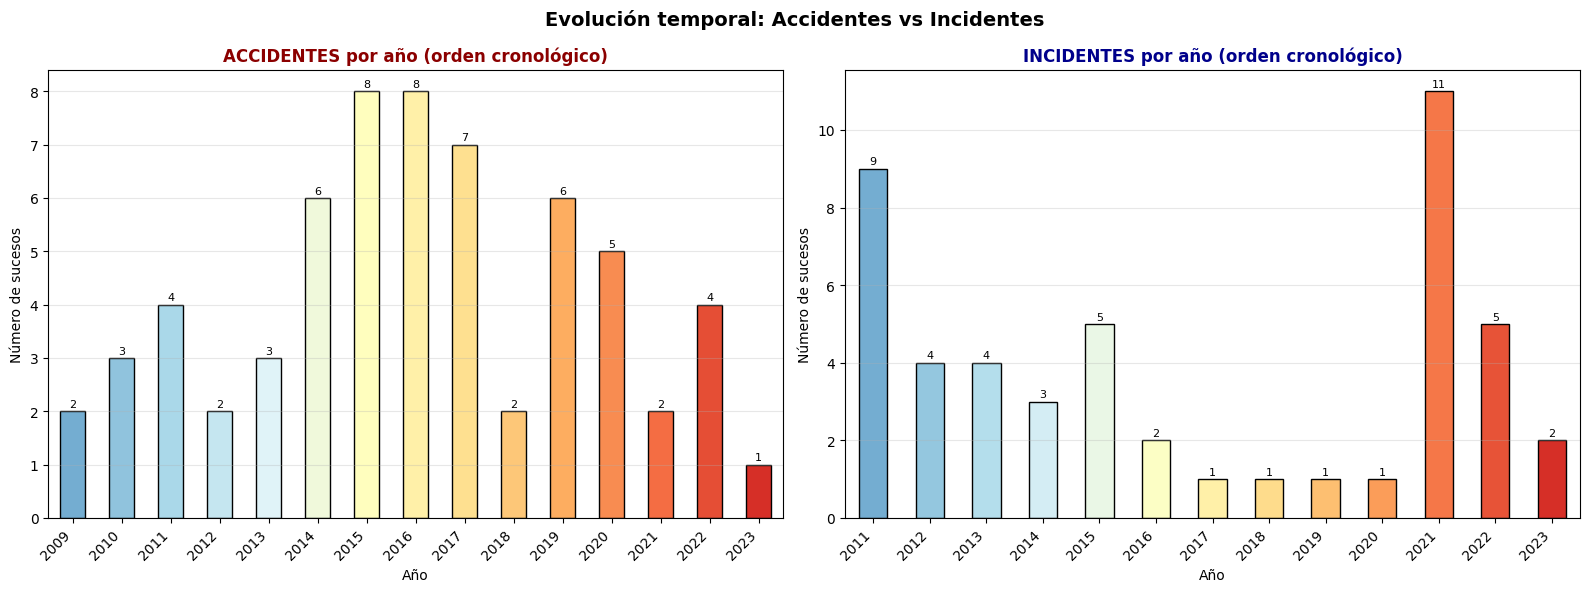

  ✓ Guardada: grafica_dual_anios_ordenado.png

2. GRÁFICAS CON VARIABLES AGRUPADAS POR RANGOS
--------------------------------------------------

 Distribución por edad del piloto


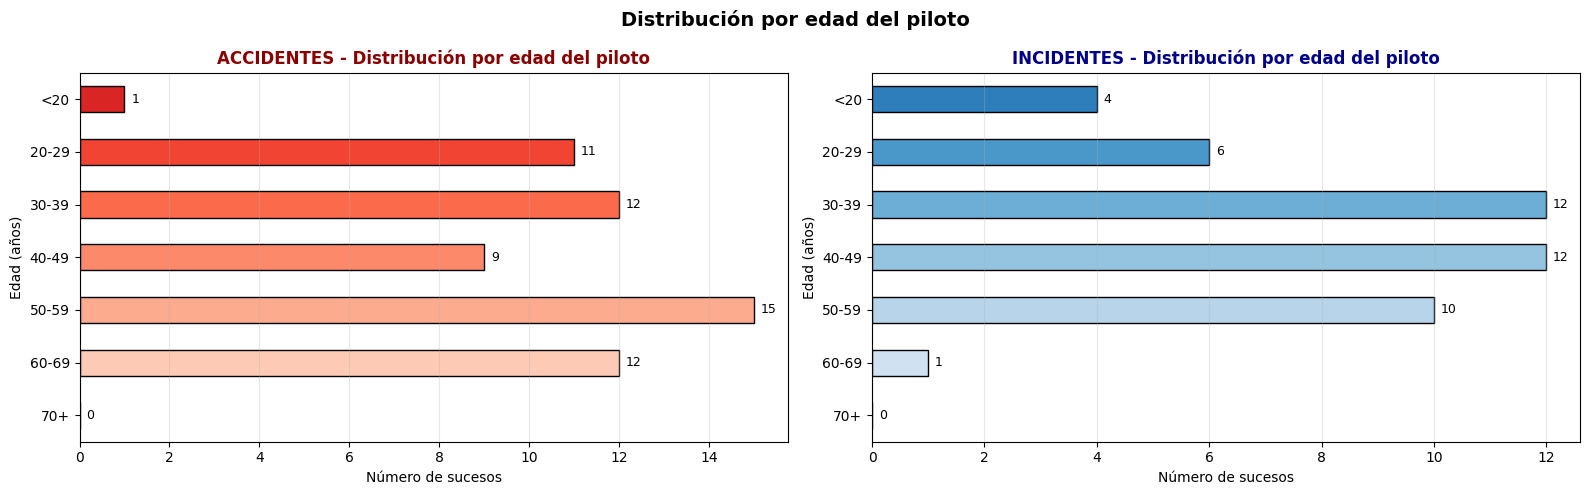

  ✓ Guardada: grafica_dual_rangos_Edad.png

 Por días desde último chequeo


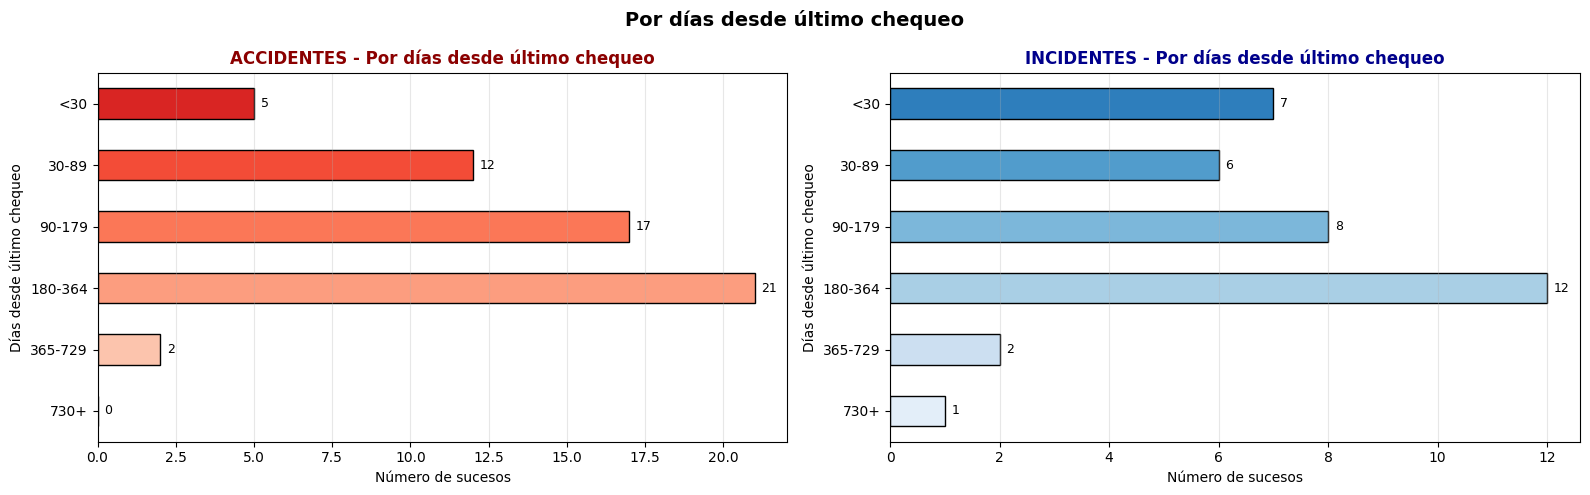

  ✓ Guardada: grafica_dual_rangos_Días_desde_último_chequeo.png

 Por horas de vuelo totales


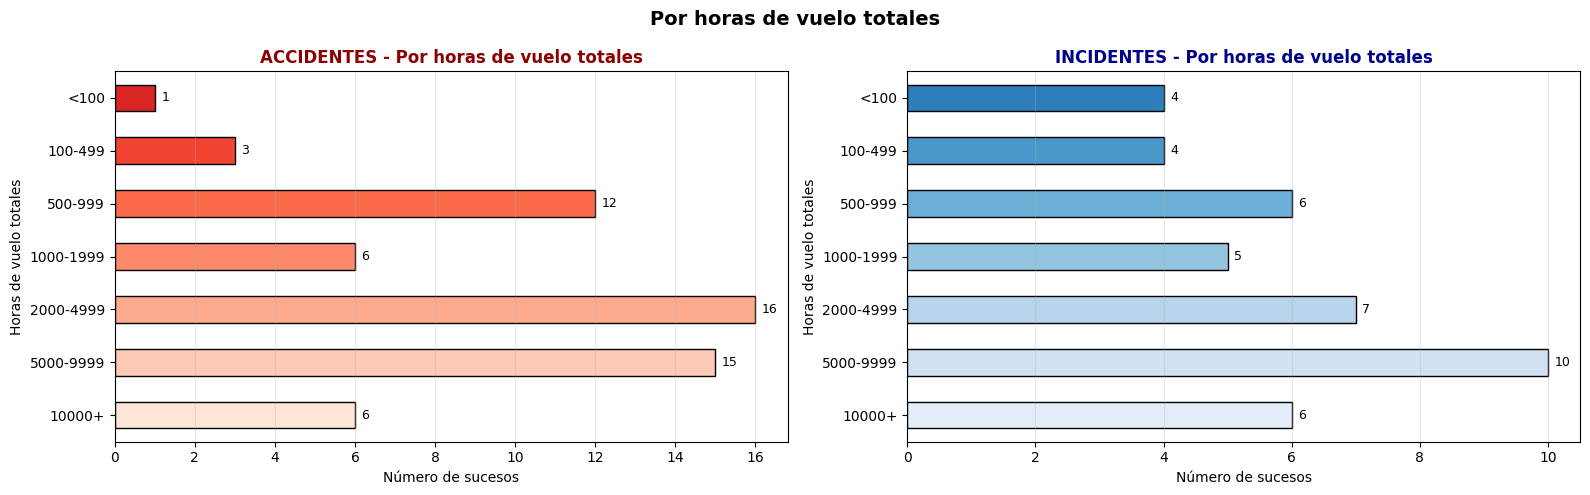

  ✓ Guardada: grafica_dual_rangos_Horas_De_Vuelo.png

 Por horas en equipo


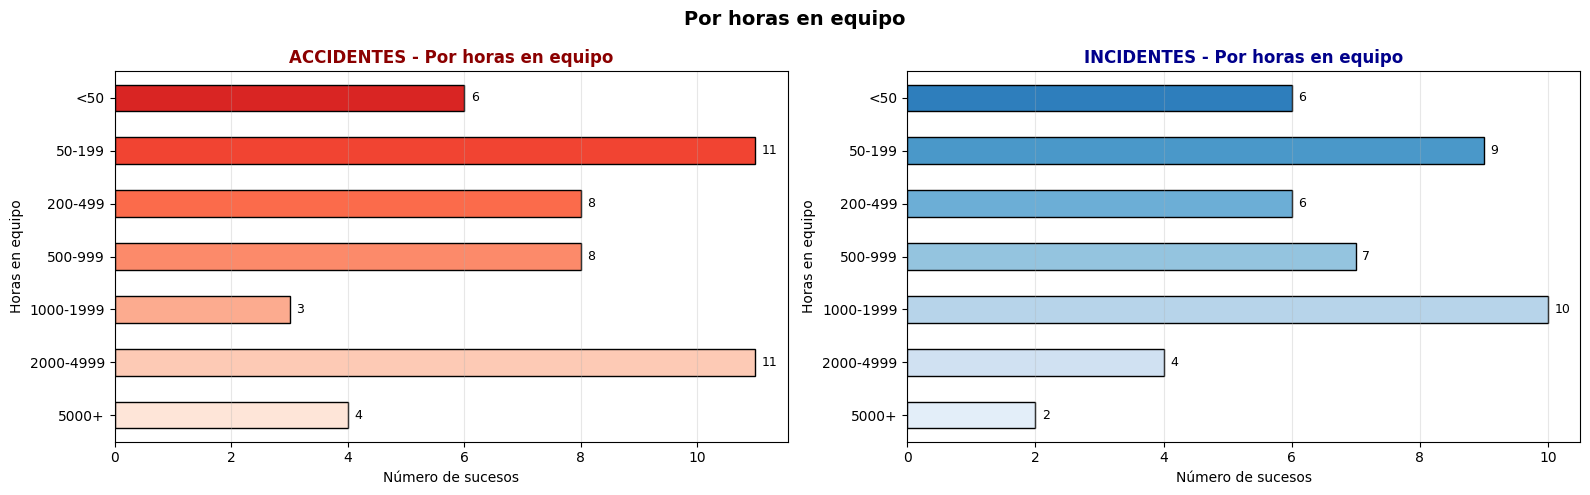

  ✓ Guardada: grafica_dual_rangos_Horas_De_Equipo.png

 Por horas en últimos 90 días


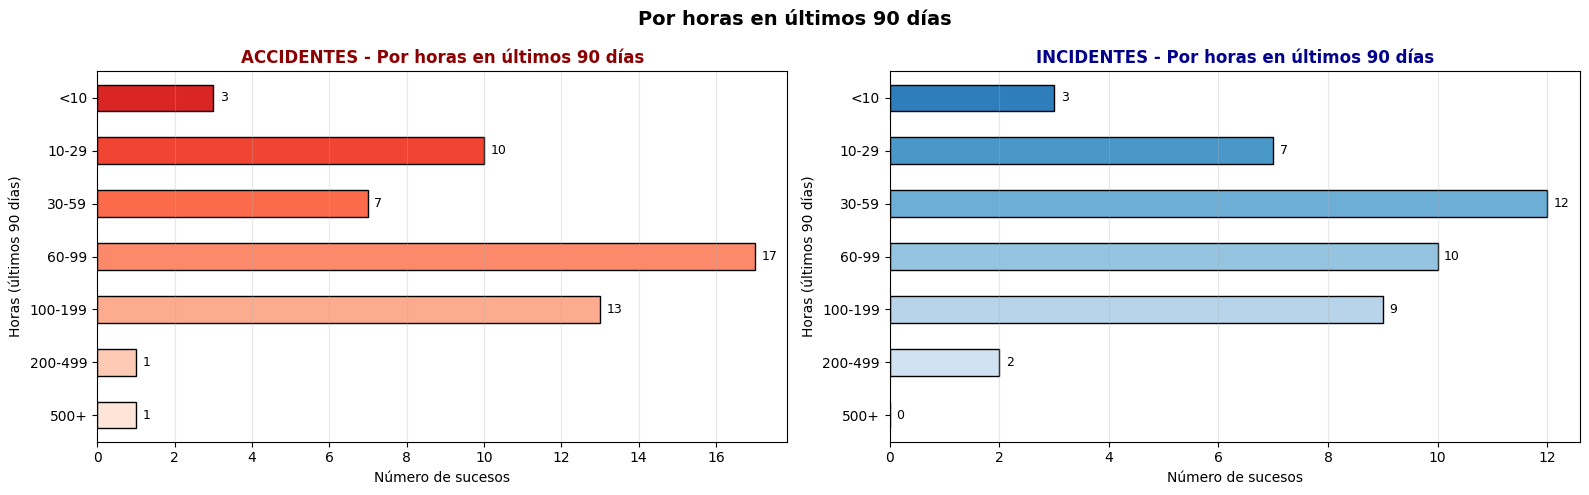

  ✓ Guardada: grafica_dual_rangos_Horas_Ultimos_90_Dias.png

 Por horas en últimos 30 días


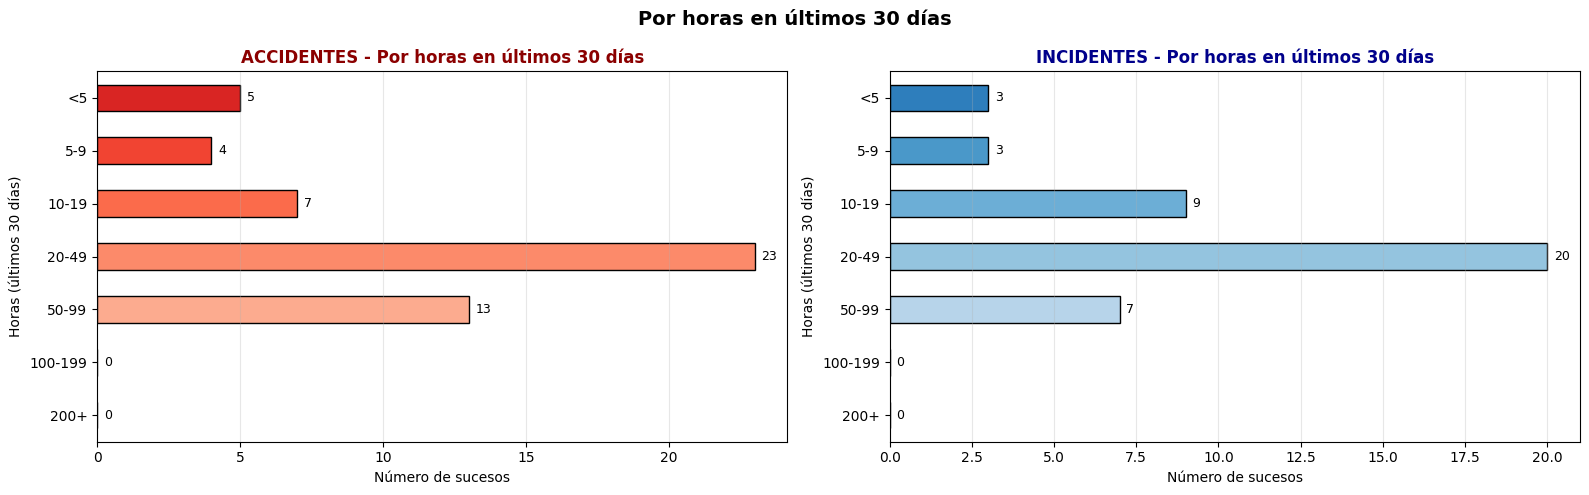

  ✓ Guardada: grafica_dual_rangos_Horas_Ultimos_30_Dias.png

 Por horas en últimos 3 días


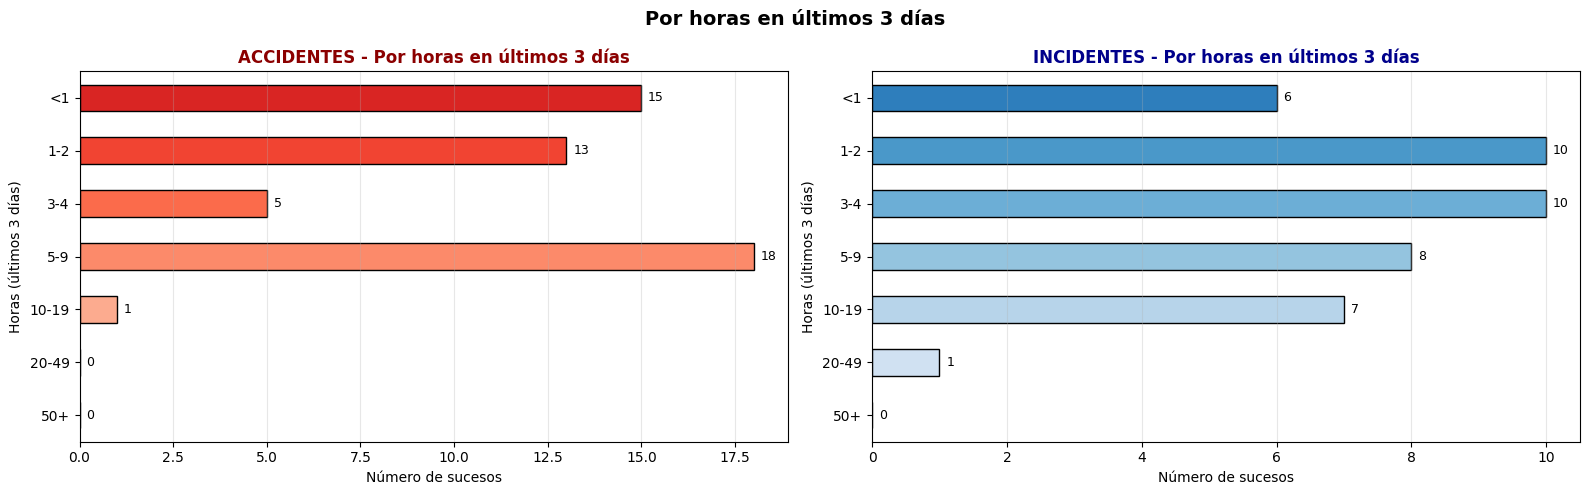

  ✓ Guardada: grafica_dual_rangos_Horas_Ultimos_03_Dias.png

 Por horas totales de aeronave


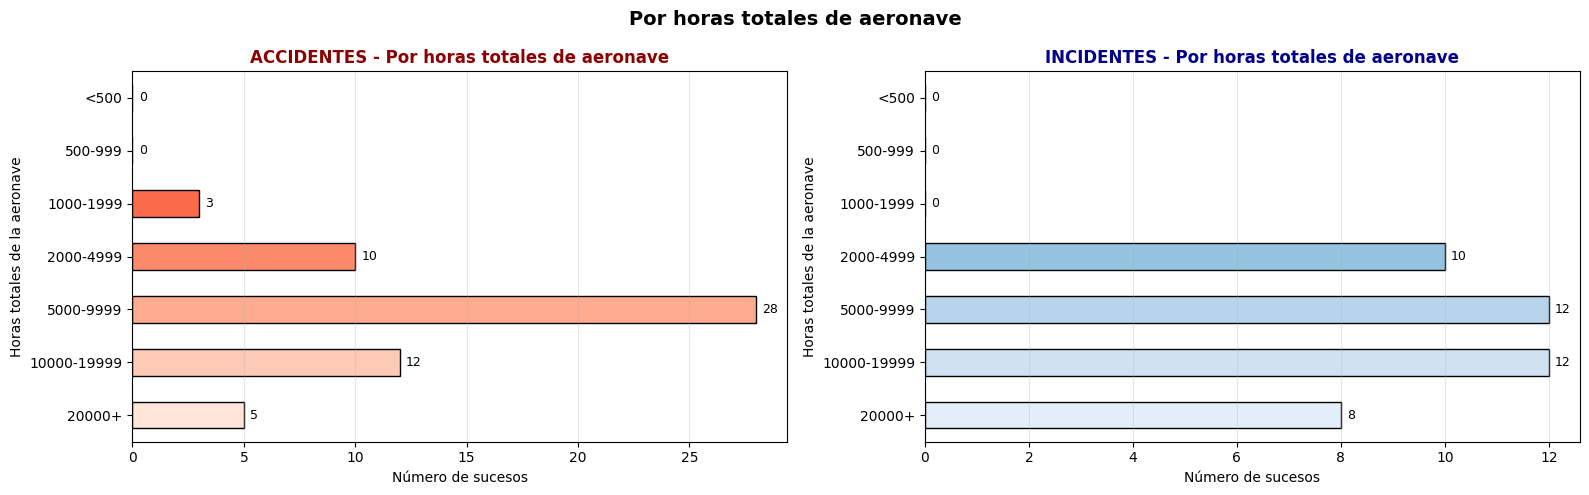

  ✓ Guardada: grafica_dual_rangos_A_-_Horas_totales.png

25. ACCIDENTES VS INCIDENTES POR AÑO DE FABRICACIÓN
--------------------------------------------------


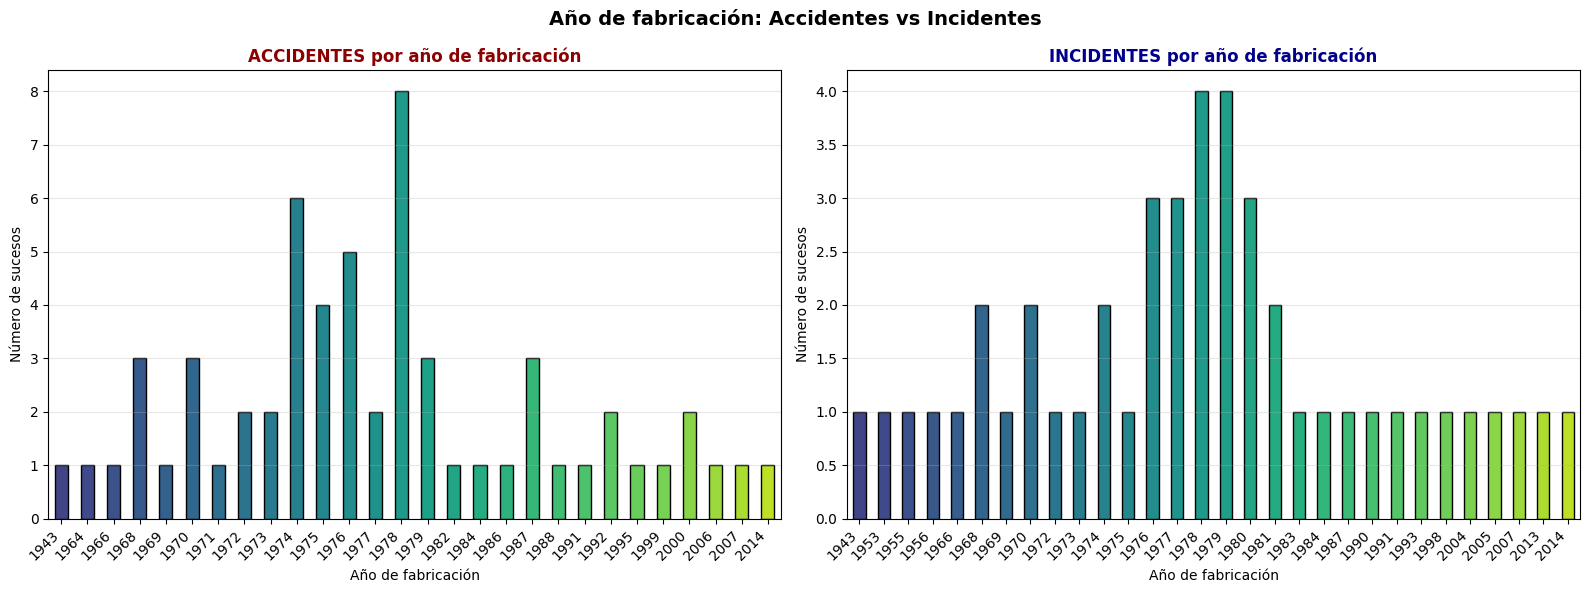

  ✓ Guardada: grafica_dual_anio_fabricacion.png

36 y 37. FACTORES HUMANOS Y OPERACIONALES - MAPEO SEMÁNTICO

📊 Factores humanos (mapeo semántico):


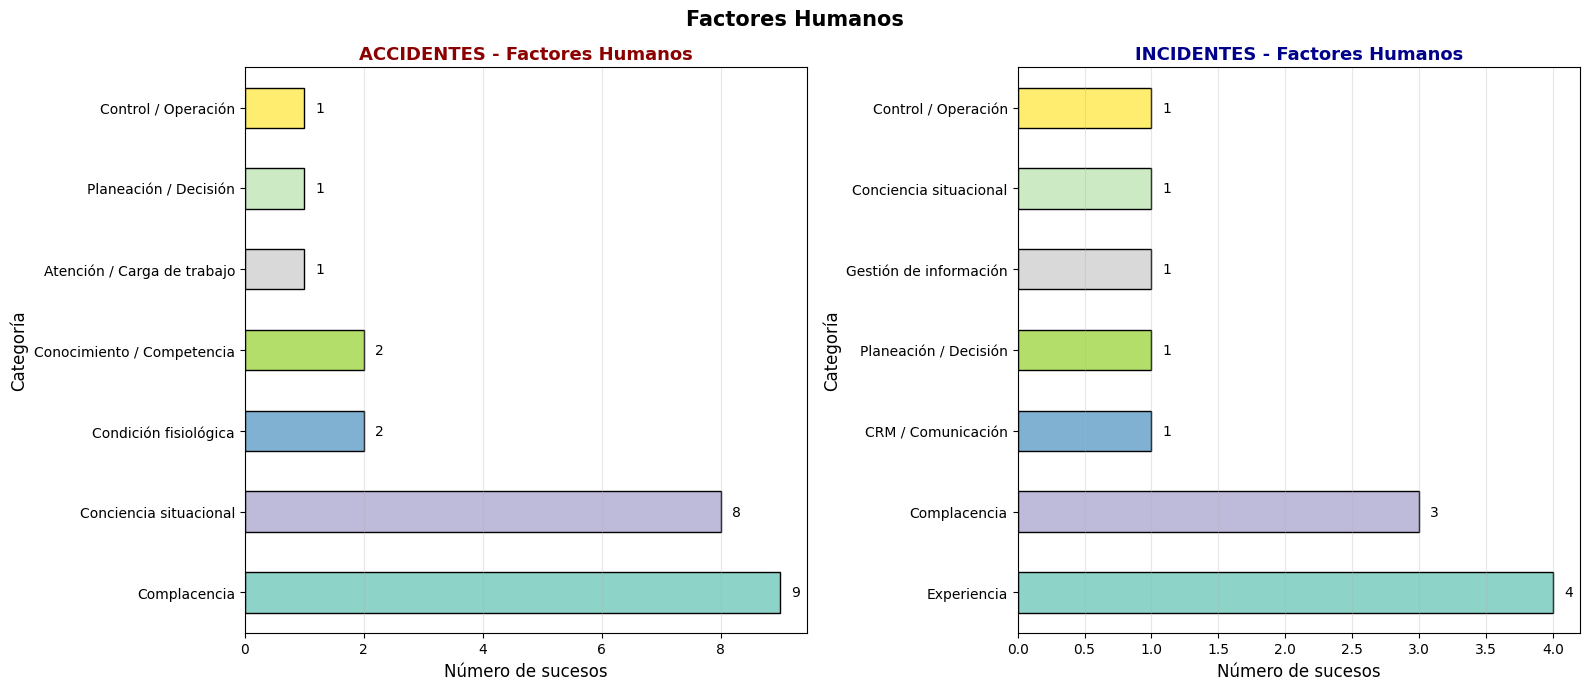

  ✓ Guardada: grafica_dual_mapeada_Humano.png

📊 Factores operacionales (mapeo semántico):


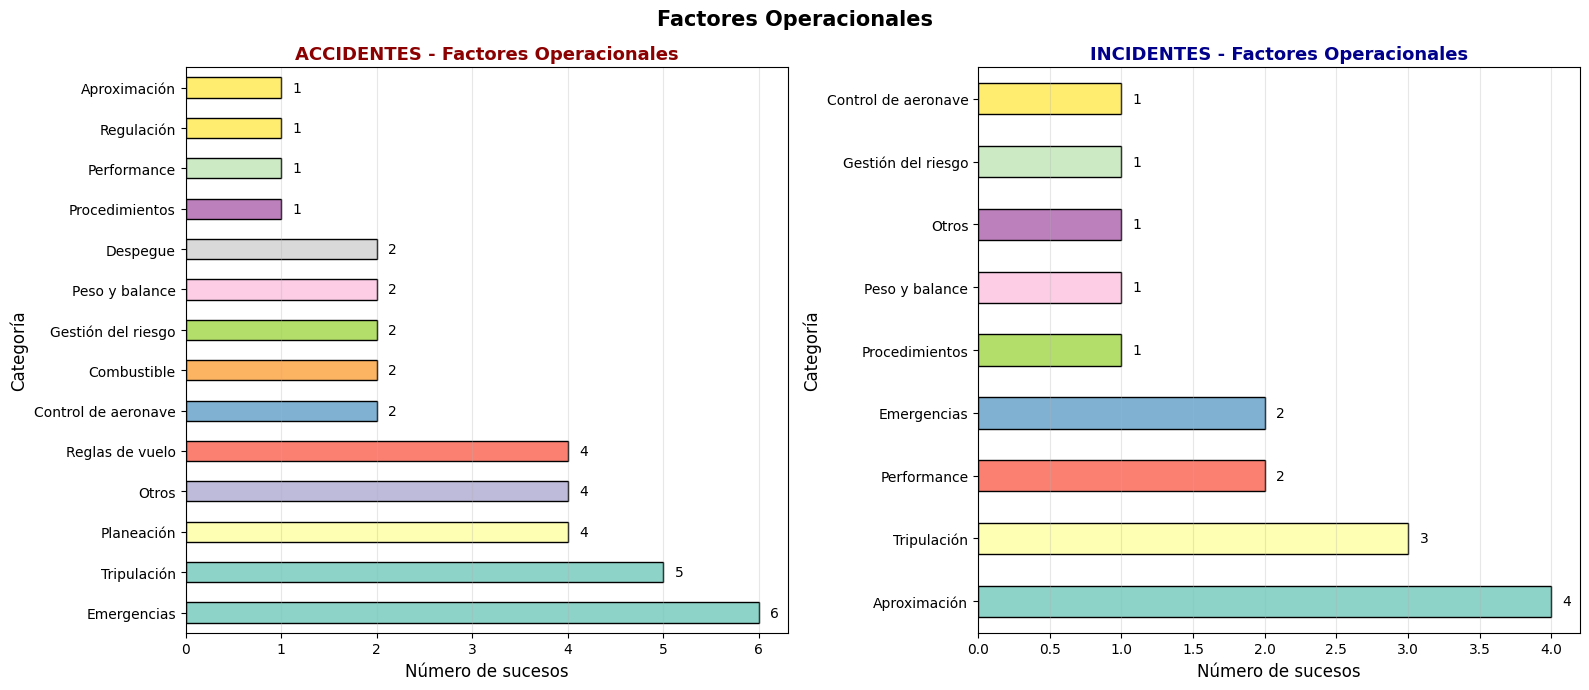

  ✓ Guardada: grafica_dual_mapeada_Operacionales.png

📋 RESUMEN DE MAPEO REALIZADO

🔹 FACTORES HUMANOS - Categorías asignadas:
   - Atención / Carga de trabajo
   - CRM / Comunicación
   - Complacencia
   - Conciencia situacional
   - Condición fisiológica
   - Conocimiento / Competencia
   - Control / Operación
   - Experiencia
   - Gestión de información
   - Planeación / Decisión

🔹 FACTORES OPERACIONALES - Categorías asignadas:
   - Aproximación
   - Combustible
   - Control de aeronave
   - Despegue
   - Emergencias
   - Gestión del riesgo
   - Motor / Sistemas
   - Navegación
   - Performance
   - Peso y balance
   - Planeación
   - Procedimientos
   - Reglas de vuelo
   - Regulación
   - Tripulación

✅ GRÁFICAS GENERADAS CON MAPEO SEMÁNTICO

GRÁFICA ADICIONAL: Condiciones de luz (orden lógico)
--------------------------------------------------


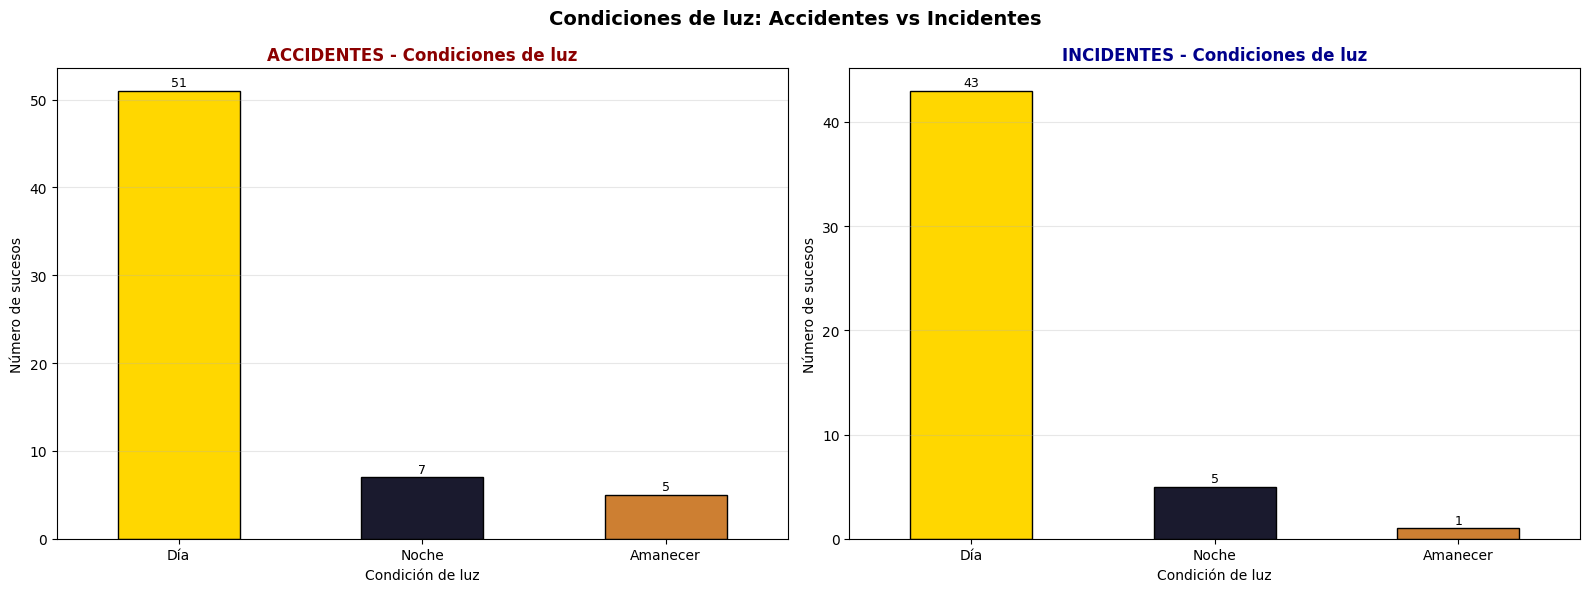

  ✓ Guardada: grafica_dual_condiciones_luz.png

RESUMEN DE GRÁFICAS GENERADAS

✓ Total de gráficas guardadas: 44

Archivos generados:
  - grafica_dual_#Motores.png
  - grafica_dual_ActAerea1.png
  - grafica_dual_Año.png
  - grafica_dual_Año_de_fabricación.png
  - grafica_dual_Condiciones_de_luz.png
  - grafica_dual_Departamento.png
  - grafica_dual_Designador.png
  - grafica_dual_Explotador.png
  - grafica_dual_Familia_motores.png
  - grafica_dual_Fase_de_vuelo.png
  - grafica_dual_Hora_del_día.png
  - grafica_dual_Humano.png
  - grafica_dual_Localización_frente_a_ad..png
  - grafica_dual_Marca_motores.png
  - grafica_dual_Misión_del_vuelo.png
  - grafica_dual_Modelo_1.png
  - grafica_dual_Municipio.png
  - grafica_dual_Nivel_de_daño_aeronave.png
  - grafica_dual_Nivel_de_lesiones.png
  - grafica_dual_Operacionales.png
  - grafica_dual_Posición.png
  - grafica_dual_Reglas_de_vuelo.png
  - grafica_dual_Taxonomía_detonante.png
  - grafica_dual_Taxonomía_preliminar.png
  - grafica_dual_Ti

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ ZIP descargado: graficas_accidentes_incidentes_mejoradas.zip

¡PROCESO COMPLETADO!


In [ ]:
# ============================================================================
# 13a. GRÁFICAS DE ACCIDENTES AÉREOS - DIFERENCIANDO ACCIDENTES VS INCIDENTES
# Con mejoras: rangos por edad, horas, años ordenados, etc.
# ============================================================================

# Configurar estilo
plt.style.use('default')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print("="*80)
print("GENERANDO GRÁFICAS - ACCIDENTES VS INCIDENTES (CON MEJORAS)")
print("="*80)

# Crear copia del DataFrame limpio
df_graph = df_limpio.copy()

# ============================================================================
# A. SEPARAR ACCIDENTES E INCIDENTES
# ============================================================================

if 'Clasificación' in df_graph.columns:
    print(f"\n Clasificaciones encontradas:")
    print(df_graph['Clasificación'].value_counts())

    # Separar Accidentes e Incidentes
    df_accidentes = df_graph[df_graph['Clasificación'].str.upper().str.contains('ACCIDENTE', na=False)].copy()
    df_incidentes = df_graph[df_graph['Clasificación'].str.upper().str.contains('INCIDENTE', na=False)].copy()

    print(f"\n✓ Accidentes: {len(df_accidentes)} registros")
    print(f"✓ Incidentes: {len(df_incidentes)} registros")
else:
    print("\n Columna 'Clasificación' no encontrada")
    df_accidentes = df_graph.copy()
    df_incidentes = pd.DataFrame()

# Extraer año y hora para ambos DataFrames
for df_temp in [df_accidentes, df_incidentes]:
    if len(df_temp) > 0:
        if 'Fecha' in df_temp.columns:
            df_temp['Año'] = pd.to_datetime(df_temp['Fecha'], errors='coerce').dt.year
        if 'Hora UTC' in df_temp.columns:
            df_temp['Hora_del_día'] = pd.to_datetime(df_temp['Hora UTC'], errors='coerce').dt.hour

# ============================================================================
# B. FUNCIÓN PARA CREAR GRÁFICAS CON RANGOS (VERSIÓN DUAL)
# ============================================================================

def graficar_con_rangos_dual(df_acc, df_inc, columna, titulo, xlabel, rangos, etiquetas_rangos=None):
    """
    Crea gráfica de barras con rangos para Accidentes e Incidentes por separado
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(rangos) * 0.4)))

    # Procesar Accidentes
    if columna in df_acc.columns and len(df_acc) > 0:
        datos_acc = df_acc[columna].dropna()
        if len(datos_acc) > 0:
            if etiquetas_rangos is None:
                etiquetas = [f"{rangos[i]}-{rangos[i+1]}" for i in range(len(rangos)-1)]
            else:
                etiquetas = etiquetas_rangos

            categorias_acc = pd.cut(datos_acc, bins=rangos, labels=etiquetas, include_lowest=True)
            conteo_acc = categorias_acc.value_counts().sort_index()

            colores_acc = plt.cm.Reds_r(np.linspace(0.3, 0.9, len(conteo_acc)))
            conteo_acc.plot(kind='barh', ax=axes[0], color=colores_acc, edgecolor='black')
            axes[0].set_xlabel("Número de sucesos")
            axes[0].set_ylabel(xlabel)
            axes[0].invert_yaxis()
            axes[0].set_title(f"ACCIDENTES - {titulo}", fontsize=12, fontweight='bold', color='darkred')
            axes[0].grid(axis='x', alpha=0.3)

            for i, (cat, val) in enumerate(conteo_acc.items()):
                axes[0].text(val + (max(conteo_acc)*0.01), i, str(val), va='center', fontsize=9)
        else:
            axes[0].text(0.5, 0.5, "Sin datos", ha='center', va='center', transform=axes[0].transAxes)
            axes[0].set_title(f"ACCIDENTES - {titulo}", fontsize=12, fontweight='bold')
    else:
        axes[0].text(0.5, 0.5, "Columna no disponible", ha='center', va='center', transform=axes[0].transAxes)
        axes[0].set_title(f"ACCIDENTES - {titulo}", fontsize=12, fontweight='bold')

    # Procesar Incidentes
    if columna in df_inc.columns and len(df_inc) > 0:
        datos_inc = df_inc[columna].dropna()
        if len(datos_inc) > 0:
            if etiquetas_rangos is None:
                etiquetas = [f"{rangos[i]}-{rangos[i+1]}" for i in range(len(rangos)-1)]
            else:
                etiquetas = etiquetas_rangos

            categorias_inc = pd.cut(datos_inc, bins=rangos, labels=etiquetas, include_lowest=True)
            conteo_inc = categorias_inc.value_counts().sort_index()

            colores_inc = plt.cm.Blues_r(np.linspace(0.3, 0.9, len(conteo_inc)))
            conteo_inc.plot(kind='barh', ax=axes[1], color=colores_inc, edgecolor='black')
            axes[1].set_xlabel("Número de sucesos")
            axes[1].set_ylabel(xlabel)
            axes[1].invert_yaxis()
            axes[1].set_title(f"INCIDENTES - {titulo}", fontsize=12, fontweight='bold', color='darkblue')
            axes[1].grid(axis='x', alpha=0.3)

            for i, (cat, val) in enumerate(conteo_inc.items()):
                axes[1].text(val + (max(conteo_inc)*0.01), i, str(val), va='center', fontsize=9)
        else:
            axes[1].text(0.5, 0.5, "Sin datos", ha='center', va='center', transform=axes[1].transAxes)
            axes[1].set_title(f"INCIDENTES - {titulo}", fontsize=12, fontweight='bold')
    else:
        axes[1].text(0.5, 0.5, "Columna no disponible", ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title(f"INCIDENTES - {titulo}", fontsize=12, fontweight='bold')

    plt.suptitle(titulo, fontsize=14, fontweight='bold')
    plt.tight_layout()
    nombre = f"grafica_dual_rangos_{columna.replace(' ', '_').replace('/', '_')}.png"
    plt.savefig(nombre, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✓ Guardada: {nombre}")

# ============================================================================
# C. GRÁFICA DE AÑOS ORDENADOS (VERSIÓN DUAL)
# ============================================================================
print("\n1. ACCIDENTES VS INCIDENTES POR AÑO (ORDENADO)")
print("-"*50)

def graficar_anios_dual(df_acc, df_inc):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, df_temp, titulo, color in zip(axes, [df_acc, df_inc], ['ACCIDENTES', 'INCIDENTES'], ['darkred', 'darkblue']):
        if 'Año' in df_temp.columns and len(df_temp) > 0:
            datos_anio = df_temp['Año'].dropna()
            if len(datos_anio) > 0:
                conteo = datos_anio.value_counts().sort_index()
                colores = plt.cm.RdYlBu_r(np.linspace(0.2, 0.9, len(conteo)))
                conteo.plot(kind='bar', ax=ax, color=colores, edgecolor='black')
                ax.set_xlabel("Año")
                ax.set_ylabel("Número de sucesos")
                ax.set_title(f"{titulo} por año (orden cronológico)", fontsize=12, fontweight='bold', color=color)
                # Formatear etiquetas del eje X sin decimales
                ax.set_xticklabels([str(int(x)) for x in conteo.index], rotation=45, ha='right')
                ax.grid(axis='y', alpha=0.3)
                for i, (anio, val) in enumerate(conteo.items()):
                    ax.text(i, val + (max(conteo)*0.01), str(val), ha='center', fontsize=8)
            else:
                ax.text(0.5, 0.5, "Sin datos", ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f"{titulo} por año", fontsize=12, fontweight='bold')
        else:
            ax.text(0.5, 0.5, "Columna no disponible", ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{titulo} por año", fontsize=12, fontweight='bold')

    plt.suptitle("Evolución temporal: Accidentes vs Incidentes", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('grafica_dual_anios_ordenado.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ Guardada: grafica_dual_anios_ordenado.png")

graficar_anios_dual(df_accidentes, df_incidentes)

# ============================================================================
# D. GRÁFICAS CON RANGOS
# ============================================================================
print("\n2. GRÁFICAS CON VARIABLES AGRUPADAS POR RANGOS")
print("-"*50)

configuraciones_rangos = [
    ('Edad', "Distribución por edad del piloto", "Edad (años)",
     [0, 20, 30, 40, 50, 60, 70, 100],
     ["<20", "20-29", "30-39", "40-49", "50-59", "60-69", "70+"]),
    ('Días desde último chequeo', "Por días desde último chequeo", "Días desde último chequeo",
     [0, 30, 90, 180, 365, 730, 10000],
     ["<30", "30-89", "90-179", "180-364", "365-729", "730+"]),
    ('Horas De Vuelo', "Por horas de vuelo totales", "Horas de vuelo totales",
     [0, 100, 500, 1000, 2000, 5000, 10000, 50000],
     ["<100", "100-499", "500-999", "1000-1999", "2000-4999", "5000-9999", "10000+"]),
    ('Horas De Equipo', "Por horas en equipo", "Horas en equipo",
     [0, 50, 200, 500, 1000, 2000, 5000, 50000],
     ["<50", "50-199", "200-499", "500-999", "1000-1999", "2000-4999", "5000+"]),
    ('Horas Ultimos 90 Dias', "Por horas en últimos 90 días", "Horas (últimos 90 días)",
     [0, 10, 30, 60, 100, 200, 500, 10000],
     ["<10", "10-29", "30-59", "60-99", "100-199", "200-499", "500+"]),
    ('Horas Ultimos 30 Dias', "Por horas en últimos 30 días", "Horas (últimos 30 días)",
     [0, 5, 10, 20, 50, 100, 200, 10000],
     ["<5", "5-9", "10-19", "20-49", "50-99", "100-199", "200+"]),
    ('Horas Ultimos 03 Dias', "Por horas en últimos 3 días", "Horas (últimos 3 días)",
     [0, 1, 3, 5, 10, 20, 50, 10000],
     ["<1", "1-2", "3-4", "5-9", "10-19", "20-49", "50+"]),
    ('A - Horas totales', "Por horas totales de aeronave", "Horas totales de la aeronave",
     [0, 500, 1000, 2000, 5000, 10000, 20000, 50000],
     ["<500", "500-999", "1000-1999", "2000-4999", "5000-9999", "10000-19999", "20000+"]),
]

for columna, titulo, xlabel, rangos, etiquetas in configuraciones_rangos:
    print(f"\n {titulo}")
    graficar_con_rangos_dual(df_accidentes, df_incidentes, columna, titulo, xlabel, rangos, etiquetas)

# ============================================================================
# E. GRÁFICA 25: Año de fabricación (dual) - CORREGIDO: años sin decimales
# ============================================================================
print("\n25. ACCIDENTES VS INCIDENTES POR AÑO DE FABRICACIÓN")
print("-"*50)

def graficar_anio_fabricacion_dual(df_acc, df_inc):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, df_temp, titulo, color in zip(axes, [df_acc, df_inc], ['ACCIDENTES', 'INCIDENTES'], ['darkred', 'darkblue']):
        if 'Año de fabricación' in df_temp.columns and len(df_temp) > 0:
            datos = df_temp['Año de fabricación'].dropna()
            datos = datos[(datos >= 1900) & (datos <= 2025)]
            if len(datos) > 0:
                conteo = datos.value_counts().sort_index()
                if len(conteo) > 30:
                    conteo = conteo.head(30)
                colores = plt.cm.viridis(np.linspace(0.2, 0.9, len(conteo)))
                conteo.plot(kind='bar', ax=ax, color=colores, edgecolor='black')
                ax.set_xlabel("Año de fabricación")
                ax.set_ylabel("Número de sucesos")
                ax.set_title(f"{titulo} por año de fabricación", fontsize=12, fontweight='bold', color=color)
                # Formatear años sin decimales
                ax.set_xticklabels([str(int(x)) for x in conteo.index], rotation=45, ha='right')
                ax.grid(axis='y', alpha=0.3)
                if len(conteo) <= 20:
                    for i, (anio, val) in enumerate(conteo.items()):
                        ax.text(i, val + (max(conteo)*0.01), str(val), ha='center', fontsize=8)
            else:
                ax.text(0.5, 0.5, "Sin datos", ha='center', va='center', transform=ax.transAxes)
        else:
            ax.text(0.5, 0.5, "Columna no disponible", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{titulo} por año de fabricación", fontsize=12, fontweight='bold')

    plt.suptitle("Año de fabricación: Accidentes vs Incidentes", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('grafica_dual_anio_fabricacion.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ Guardada: grafica_dual_anio_fabricacion.png")

graficar_anio_fabricacion_dual(df_accidentes, df_incidentes)

# ============================================================================
# F. DICCIONARIOS DE MAPEO PARA FACTORES HUMANOS Y OPERACIONALES
# ============================================================================

# Diccionario para mapear textos originales a categorías resumidas (HUMANOS)
mapeo_humano = {
    # Texto original (puede contener parte del texto) -> (resumen, categoria)
    "Debilidades en la asertividad de las comunicaciones (CRM)": ("Fallas en comunicación CRM cabina", "CRM / Comunicación"),
    "no informar el PF las intenciones de navegación al PM": ("Fallas en comunicación CRM cabina", "CRM / Comunicación"),
    "desaprovechamiento de los recursos de cabina": ("Fallas en comunicación CRM cabina", "CRM / Comunicación"),
    "Exceso de confianza del PF": ("Complacencia operacional del piloto", "Complacencia"),
    "sesgó su juicio": ("Complacencia operacional del piloto", "Complacencia"),
    "Desatención por parte del piloto": ("Atención deficiente en cabina", "Atención / Carga de trabajo"),
    "focalizar su atención en el GPS": ("Atención deficiente en cabina", "Atención / Carga de trabajo"),
    "Deficiente planeación del vuelo (Gestión del combustible)": ("Planeación deficiente de vuelo", "Planeación / Decisión"),
    "Deficiente planeación del vuelo": ("Planeación deficiente de vuelo", "Planeación / Decisión"),
    "Complacencia (Condición meteorológicas)": ("Complacencia operacional del piloto", "Complacencia"),
    "Complacencia (Condición de la aeronave)": ("Complacencia operacional del piloto", "Complacencia"),
    "Complacencia (Condiciones de pista)": ("Complacencia operacional del piloto", "Complacencia"),
    "Pérdida de conciencia situacional": ("Pérdida de conciencia situacional", "Conciencia situacional"),
    "Incapacitación Súbita": ("Incapacitación de la tripulación", "Condición fisiológica"),
    "Desconocimiento conceptos de vuelo": ("Falta de conocimiento técnico", "Conocimiento / Competencia"),
    "Información de registradores eliminada": ("Gestión inadecuada de información", "Gestión de información"),
    "Baja continuidad de vuelo": ("Experiencia operativa limitada", "Experiencia"),
    "Limitada experiencia": ("Experiencia operativa limitada", "Experiencia"),
    "Operación brusca de componentes": ("Control inadecuado de aeronave", "Control / Operación"),
}

# Diccionario para mapear textos originales a categorías resumidas (OPERACIONALES)
mapeo_operacional = {
    # Procedimientos
    "omisión de la ejecución estricta del procedimiento": ("Incumplimiento de procedimientos operacionales", "Procedimientos"),
    "No aplicación de maniobras de emergencia": ("Gestión deficiente de emergencias", "Emergencias"),
    "Deficientes procedimientos de emergencia": ("Gestión deficiente de emergencias", "Emergencias"),
    "deficientes procedimientos de emergencia": ("Gestión deficiente de emergencias", "Emergencias"),
    "Deficientes procedimientos de emergencia en la escogencia del lugar": ("Gestión deficiente de emergencias", "Emergencias"),
    "Desviación de las limitantes operacionales del Fabricante": ("Incumplimiento de procedimientos operacionales", "Procedimientos"),
    "Maniobra no autorizada": ("Incumplimiento de procedimientos operacionales", "Procedimientos"),

    # Gestión del riesgo / Planeación
    "Deficiente identificación de obstáculos": ("Identificación deficiente de peligros", "Gestión del riesgo"),
    "Deficiente evaluación del riesgo": ("Gestión deficiente del riesgo", "Gestión del riesgo"),
    "deficiente evaluación del riesgo": ("Gestión deficiente del riesgo", "Gestión del riesgo"),
    "Deficiente planeación del vuelo, identificación de peligros": ("Planeación deficiente de vuelo", "Planeación"),
    "deficiente planeación de vuelo": ("Planeación deficiente de vuelo", "Planeación"),
    "deficiente planeación del vuelo - meteorologia": ("Planeación deficiente de vuelo", "Planeación"),
    "no identificación de peligros en ruta": ("Identificación deficiente de peligros", "Gestión del riesgo"),

    # Performance / Despegue / Aproximación
    "Ejecución de un despegue en condiciones limitadas de rendimiento": ("Performance insuficiente de despegue", "Performance"),
    "Deficiente calculo de la longitud de pista requerida": ("Planeación deficiente de performance", "Performance"),
    "deficiente planeación del vuelo - longitud de pista": ("Planeación deficiente de performance", "Performance"),
    "Inapropiada técnica de despegue - rotación prematura": ("Técnica incorrecta de despegue", "Despegue"),
    "inapropiada técnica de despegue - rotación prematura": ("Técnica incorrecta de despegue", "Despegue"),
    "Ejecución de aproximación desestabilizada": ("Aproximación desestabilizada", "Aproximación"),
    "ejecución de aproximación desestabilizada": ("Aproximación desestabilizada", "Aproximación"),

    # Control de aeronave / Motor
    "Inapropiada maniobra de viraje": ("Control inadecuado de aeronave", "Control de aeronave"),
    "Inadecuada maniobra en vuelo": ("Control inadecuado de aeronave", "Control de aeronave"),
    "Inapropiado ajuste de la mezcla Aire/Combustible": ("Configuración incorrecta de motor", "Motor / Sistemas"),
    "Deficiente uso de los Flaps": ("Configuración incorrecta de aeronave", "Control de aeronave"),

    # Peso y balance
    "Distribución asimétrica de la carga transportada": ("Gestión inadecuada de carga", "Peso y balance"),
    "Operación con sobre peso": ("Peso y balance inadecuado", "Peso y balance"),
    "sobrepeso": ("Peso y balance inadecuado", "Peso y balance"),
    "sobre peso - deficientes procedimientos de emergencia": ("Peso y balance inadecuado", "Peso y balance"),
    "deficiente planeación de vuelo - incorrecto aseguramiento de la carga externa": ("Gestión inadecuada de carga", "Peso y balance"),

    # Reglas de vuelo
    "Ejecución del vuelo sin respetar alturas minimas - vmc en imc": ("Incumplimiento de reglas de vuelo", "Reglas de vuelo"),
    "realización de vuelo vmc en condiciones meteorologicas imc": ("Incumplimiento de reglas de vuelo", "Reglas de vuelo"),
    "vuelos a alturas inferiores a las establecidas": ("Incumplimiento de mínimos operacionales", "Regulación"),

    # Combustible
    "carga incorrecta de combustible": ("Gestión deficiente de combustible", "Combustible"),
    "deficiencias procedimientos de seguridad en cabina - carga incorrecta de combustible": ("Gestión deficiente de combustible", "Combustible"),

    # Tripulación
    "inapropiada ejecución de la tripulación": ("Desempeño deficiente de tripulación", "Tripulación"),
    "Omisión por parte de la tripulación": ("Incumplimiento de procedimientos operacionales", "Procedimientos"),

    # Navegación
    "ausencia de cartas aeronauticas": ("Gestión deficiente de navegación", "Navegación"),
}

# ============================================================================
# G. FUNCIÓN PARA APLICAR EL MAPEO
# ============================================================================

def mapear_factor_humano(texto):
    """Mapea texto original a (resumen, categoria) para factores humanos"""
    if not isinstance(texto, str):
        return ("Sin clasificar", "Sin clasificar")

    for clave, (resumen, categoria) in mapeo_humano.items():
        if clave.lower() in texto.lower():
            return (resumen, categoria)

    # Si no encuentra coincidencia, devolver texto truncado
    texto_corto = texto[:50] + "..." if len(texto) > 50 else texto
    return (texto_corto, "Otros")

def mapear_factor_operacional(texto):
    """Mapea texto original a (resumen, categoria) para factores operacionales"""
    if not isinstance(texto, str):
        return ("Sin clasificar", "Sin clasificar")

    for clave, (resumen, categoria) in mapeo_operacional.items():
        if clave.lower() in texto.lower():
            return (resumen, categoria)

    # Si no encuentra coincidencia, devolver texto truncado
    texto_corto = texto[:50] + "..." if len(texto) > 50 else texto
    return (texto_corto, "Otros")

# ============================================================================
# H. GRÁFICAS CON MAPEO SEMÁNTICO (VERSIÓN FINAL)
# ============================================================================
print("\n" + "="*80)
print("36 y 37. FACTORES HUMANOS Y OPERACIONALES - MAPEO SEMÁNTICO")
print("="*80)

def graficar_factores_mapeados(df_acc, df_inc, columna, titulo, mapeador):
    """
    Genera gráfica de barras con factores agrupados según mapeo semántico
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    resultados = []

    for ax, df_temp, subtitulo, color in zip(axes, [df_acc, df_inc],
                                               ['ACCIDENTES', 'INCIDENTES'],
                                               ['darkred', 'darkblue']):
        if columna in df_temp.columns and len(df_temp) > 0:
            datos = df_temp[columna].dropna()
            if len(datos) > 0:
                # Aplicar mapeo
                categorias = datos.apply(mapeador)

                # Separar resumen y categoría
                resumenes = categorias.apply(lambda x: x[0])
                categorias_principales = categorias.apply(lambda x: x[1])

                # Contar por categoría principal
                conteo = categorias_principales.value_counts()

                colores_barra = plt.cm.Set3(np.linspace(0, 1, len(conteo)))
                conteo.plot(kind='barh', ax=ax, color=colores_barra, edgecolor='black')
                ax.set_xlabel("Número de sucesos", fontsize=12)
                ax.set_ylabel("Categoría", fontsize=12)
                ax.set_title(f"{subtitulo} - {titulo}", fontsize=13, fontweight='bold', color=color)
                ax.grid(axis='x', alpha=0.3)

                # Añadir valores
                for i, (cat, val) in enumerate(conteo.items()):
                    ax.text(val + (max(conteo)*0.02), i, str(val), va='center', fontsize=10)

                # Guardar resultado para mostrar
                resultados.append(conteo)

            else:
                ax.text(0.5, 0.5, "Sin datos", ha='center', va='center', transform=ax.transAxes)
        else:
            ax.text(0.5, 0.5, "Columna no disponible", ha='center', va='center', transform=ax.transAxes)

    plt.suptitle(titulo, fontsize=15, fontweight='bold')
    plt.tight_layout()
    nombre = f"grafica_dual_mapeada_{columna}.png"
    plt.savefig(nombre, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✓ Guardada: {nombre}")

    return resultados

# ============================================================================
# I. EJECUTAR GRÁFICAS
# ============================================================================

print("\n📊 Factores humanos (mapeo semántico):")
resultados_humanos = graficar_factores_mapeados(df_accidentes, df_incidentes,
                                                 'Humano', "Factores Humanos",
                                                 mapear_factor_humano)

print("\n📊 Factores operacionales (mapeo semántico):")
resultados_operacionales = graficar_factores_mapeados(df_accidentes, df_incidentes,
                                                       'Operacionales', "Factores Operacionales",
                                                       mapear_factor_operacional)

# ============================================================================
# J. MOSTRAR TABLA DE MAPEO REALIZADO
# ============================================================================
print("\n" + "="*80)
print("📋 RESUMEN DE MAPEO REALIZADO")
print("="*80)

print("\n🔹 FACTORES HUMANOS - Categorías asignadas:")
categorias_humanos = set()
for clave, (resumen, categoria) in mapeo_humano.items():
    categorias_humanos.add(categoria)
for cat in sorted(categorias_humanos):
    print(f"   - {cat}")

print("\n🔹 FACTORES OPERACIONALES - Categorías asignadas:")
categorias_operacionales = set()
for clave, (resumen, categoria) in mapeo_operacional.items():
    categorias_operacionales.add(categoria)
for cat in sorted(categorias_operacionales):
    print(f"   - {cat}")

print("\n" + "="*80)
print("✅ GRÁFICAS GENERADAS CON MAPEO SEMÁNTICO")
print("="*80)

# ============================================================================
# H. GRÁFICA ADICIONAL: Condiciones de luz (orden lógico) - DUAL
# ============================================================================
print("\nGRÁFICA ADICIONAL: Condiciones de luz (orden lógico)")
print("-"*50)

def graficar_luz_dual(df_acc, df_inc):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    orden_luz = ['Día', 'Noche', 'Crepúsculo', 'Anochecer', 'Amanecer', 'No reportado']
    colores_luz = ['#FFD700', '#1a1a2e', '#cd7f32', '#ff8c00', '#87ceeb', '#808080']

    for ax, df_temp, subtitulo, color in zip(axes, [df_acc, df_inc], ['ACCIDENTES', 'INCIDENTES'], ['darkred', 'darkblue']):
        if 'Condiciones de luz' in df_temp.columns and len(df_temp) > 0:
            datos = df_temp['Condiciones de luz'].dropna()
            if len(datos) > 0:
                conteo = datos.value_counts()
                conteo_ordenado = pd.Series()
                for cat in orden_luz:
                    if cat in conteo.index:
                        conteo_ordenado[cat] = conteo[cat]
                for cat in conteo.index:
                    if cat not in conteo_ordenado.index:
                        conteo_ordenado[cat] = conteo[cat]
                conteo_ordenado.plot(kind='bar', ax=ax, color=colores_luz[:len(conteo_ordenado)], edgecolor='black')
                ax.set_xlabel("Condición de luz")
                ax.set_ylabel("Número de sucesos")
                ax.set_title(f"{subtitulo} - Condiciones de luz", fontsize=12, fontweight='bold', color=color)
                ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
                ax.grid(axis='y', alpha=0.3)
                for i, (cat, val) in enumerate(conteo_ordenado.items()):
                    ax.text(i, val + (max(conteo_ordenado)*0.01), str(val), ha='center', fontsize=9)
            else:
                ax.text(0.5, 0.5, "Sin datos", ha='center', va='center', transform=ax.transAxes)
        else:
            ax.text(0.5, 0.5, "Columna no disponible", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{subtitulo} - Condiciones de luz", fontsize=12, fontweight='bold')

    plt.suptitle("Condiciones de luz: Accidentes vs Incidentes", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('grafica_dual_condiciones_luz.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ Guardada: grafica_dual_condiciones_luz.png")

graficar_luz_dual(df_accidentes, df_incidentes)

# ============================================================================
# I. RESUMEN Y DESCARGA
# ============================================================================
print("\n" + "="*80)
print("RESUMEN DE GRÁFICAS GENERADAS")
print("="*80)

archivos_png = glob.glob('grafica_dual_*.png')
print(f"\n✓ Total de gráficas guardadas: {len(archivos_png)}")

print("\nArchivos generados:")
for archivo in sorted(archivos_png):
    print(f"  - {archivo}")

!zip -r graficas_accidentes_incidentes_mejoradas.zip grafica_dual_*.png
files.download('graficas_accidentes_incidentes_mejoradas.zip')

print("\n✓ ZIP descargado: graficas_accidentes_incidentes_mejoradas.zip")
print("\n" + "="*80)
print("¡PROCESO COMPLETADO!")
print("="*80)

In [ ]:
# ============================================================================
# 14. MAPA DE ACCIDENTES E INCIDENTES AÉREOS EN COLOMBIA (SOLO CÍRCULOS)
# ============================================================================

print("="*80)
print("GENERANDO MAPA DE ACCIDENTES E INCIDENTES AÉREOS EN COLOMBIA")
print("="*80)

# ============================================================================
# A. PREPARACIÓN DE DATOS
# ============================================================================

df_mapa = df_limpio.copy()
print(f"\n Datos iniciales: {df_mapa.shape[0]} registros")

if 'LAT GMS' not in df_mapa.columns or 'LONG GMS' not in df_mapa.columns:
    print(" Columnas 'LAT GMS' y/o 'LONG GMS' no encontradas")
else:
    print("✓ Columnas de coordenadas encontradas")

# ============================================================================
# B. COORDENADAS
# ============================================================================

df_mapa['LAT_DEC'] = pd.to_numeric(df_mapa['LAT GMS'], errors='coerce')
df_mapa['LONG_DEC'] = pd.to_numeric(df_mapa['LONG GMS'], errors='coerce')

coords_validas = df_mapa['LAT_DEC'].notna() & df_mapa['LONG_DEC'].notna()

print(f"✓ Coordenadas válidas: {coords_validas.sum()}")
print(f"✗ Coordenadas inválidas: {(~coords_validas).sum()}")

# ============================================================================
# C. DIAGNÓSTICO DE CLASIFICACIÓN
# ============================================================================

print("\n" + "="*80)
print("DIAGNÓSTICO - VALORES EN COLUMNA 'Clasificación'")
print("="*80)

if 'Clasificación' in df_mapa.columns:
    print("\nValores únicos en 'Clasificación':")
    for valor in df_mapa['Clasificación'].unique():
        print(f"  - '{valor}'")

    print("\nFrecuencias:")
    print(df_mapa['Clasificación'].value_counts())
else:
    print(" Columna 'Clasificación' no encontrada")

# ============================================================================
# D. FILTROS
# ============================================================================

df_mapa_validos = df_mapa[coords_validas].copy()

# Filtrar accidentes
df_accidentes_mapa = df_mapa_validos[df_mapa_validos['Clasificación'].str.upper().str.contains('ACCIDENTE', na=False, regex=False)]

# Filtrar incidentes
df_incidentes_mapa = df_mapa_validos[df_mapa_validos['Clasificación'].str.upper().str.contains('INCIDENTE', na=False, regex=False)]

print(f"\n Resultados del filtrado:")
print(f"  - Accidentes: {len(df_accidentes_mapa)}")
print(f"  - Incidentes: {len(df_incidentes_mapa)}")

# ============================================================================
# E. MAPA BASE
# ============================================================================

if len(df_accidentes_mapa) > 0 or len(df_incidentes_mapa) > 0:
    df_temp = pd.concat([df_accidentes_mapa, df_incidentes_mapa])
    centro_lat = df_temp['LAT_DEC'].mean()
    centro_lon = df_temp['LONG_DEC'].mean()
else:
    centro_lat = 4.5709
    centro_lon = -74.2973

mapa = folium.Map(
    location=[centro_lat, centro_lon],
    zoom_start=6,
    tiles='CartoDB positron'
)

# ============================================================================
# F. ACCIDENTES (CÍRCULOS ROJOS - SIN ICONOS)
# ============================================================================

accidentes_agregados = 0

for _, row in df_accidentes_mapa.iterrows():
    # Obtener datos
    lugar = row.get('Municipio', 'N/A')
    if pd.isna(lugar) or str(lugar).strip() == '':
        lugar = row.get('Departamento', 'N/A')

    departamento = row.get('Departamento', 'N/A')

    fecha = row.get('Fecha', 'N/A')
    if pd.notna(fecha):
        fecha = str(fecha)[:10]

    hora = row.get('Hora', 'N/A')
    if pd.isna(hora) or hora == '':
        hora = row.get('Hora UTC', 'N/A')

    matricula = row.get('Matrícula', 'N/A')
    if pd.isna(matricula) or matricula == '':
        matricula = row.get('Matrícula limpia', 'N/A')

    mision = row.get('Misión del vuelo', 'N/A')

    lat = row['LAT_DEC']
    lon = row['LONG_DEC']

    # Crear popup
    popup_text = f"""
    <div style="font-family: Arial; font-size: 12px; min-width: 250px;">
        <b style="color: darkred;">ACCIDENTE</b><br>
        <hr style="margin: 5px 0;">
        <b>Lugar:</b> {lugar}<br>
        <b>Departamento:</b> {departamento}<br>
        <b>Fecha:</b> {fecha}<br>
        <b>Hora:</b> {hora}<br>
        <b>Matricula:</b> {matricula}<br>
        <b>Mision:</b> {mision}<br>
        <b>Coordenadas:</b> {lat:.4f}, {lon:.4f}
    </div>
    """

    # Usar CircleMarker en lugar de Marker (solo círculo, sin icono)
    folium.CircleMarker(
        location=[lat, lon],
        radius=6,
        popup=folium.Popup(popup_text, max_width=350),
        tooltip=f"ACCIDENTE: {lugar} - {fecha}",
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.7
    ).add_to(mapa)
    accidentes_agregados += 1

print(f"✓ Accidentes añadidos: {accidentes_agregados}")

# ============================================================================
# G. INCIDENTES (CÍRCULOS AZULES - SIN ICONOS)
# ============================================================================

incidentes_agregados = 0

if len(df_incidentes_mapa) > 0:
    print(f"\n Procesando {len(df_incidentes_mapa)} incidentes...")

    for _, row in df_incidentes_mapa.iterrows():
        # Obtener datos
        lugar = row.get('Municipio', 'N/A')
        if pd.isna(lugar) or str(lugar).strip() == '':
            lugar = row.get('Departamento', 'N/A')

        departamento = row.get('Departamento', 'N/A')

        fecha = row.get('Fecha', 'N/A')
        if pd.notna(fecha):
            fecha = str(fecha)[:10]

        hora = row.get('Hora', 'N/A')
        if pd.isna(hora) or hora == '':
            hora = row.get('Hora UTC', 'N/A')

        matricula = row.get('Matrícula', 'N/A')
        if pd.isna(matricula) or matricula == '':
            matricula = row.get('Matrícula limpia', 'N/A')

        mision = row.get('Misión del vuelo', 'N/A')

        lat = row['LAT_DEC']
        lon = row['LONG_DEC']

        # Crear popup
        popup_text = f"""
        <div style="font-family: Arial; font-size: 12px; min-width: 250px;">
            <b style="color: darkblue;">INCIDENTE</b><br>
            <hr style="margin: 5px 0;">
            <b>Lugar:</b> {lugar}<br>
            <b>Departamento:</b> {departamento}<br>
            <b>Fecha:</b> {fecha}<br>
            <b>Hora:</b> {hora}<br>
            <b>Matricula:</b> {matricula}<br>
            <b>Mision:</b> {mision}<br>
            <b>Coordenadas:</b> {lat:.4f}, {lon:.4f}
        </div>
        """

        # Usar CircleMarker en lugar de Marker (solo círculo, sin icono)
        folium.CircleMarker(
            location=[lat, lon],
            radius=6,
            popup=folium.Popup(popup_text, max_width=350),
            tooltip=f"INCIDENTE: {lugar} - {fecha}",
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.7
        ).add_to(mapa)
        incidentes_agregados += 1

    print(f"✓ Incidentes añadidos: {incidentes_agregados}")
else:
    print("\n No hay incidentes para mostrar en el mapa")

# ============================================================================
# H. HEATMAP (solo accidentes)
# ============================================================================

heat_data = [[row['LAT_DEC'], row['LONG_DEC'], 1] for _, row in df_accidentes_mapa.iterrows()]

if heat_data:
    plugins.HeatMap(heat_data, name='Heatmap Accidentes', radius=15, blur=10).add_to(mapa)
    print("✓ Heatmap de accidentes añadido")

# ============================================================================
# I. CONTROLES
# ============================================================================

plugins.MiniMap().add_to(mapa)
plugins.Fullscreen().add_to(mapa)
folium.LayerControl().add_to(mapa)

# ============================================================================
# J. MOSTRAR MAPA
# ============================================================================

nombre_mapa = "mapa_accidentes_incidentes.html"
mapa.save(nombre_mapa)

from IPython.display import IFrame, display
display(IFrame(nombre_mapa, width='100%', height='600px'))

# ============================================================================
# K. DESCARGAR
# ============================================================================

from google.colab import files
files.download(nombre_mapa)

# ============================================================================
# L. RESUMEN FINAL
# ============================================================================

print("\n" + "="*80)
print("RESUMEN FINAL")
print("="*80)
print(f"""
Estadisticas del mapa:
   Accidentes mostrados: {accidentes_agregados}
   Incidentes mostrados: {incidentes_agregados}
   Centro del mapa: {centro_lat:.4f}, {centro_lon:.4f}
   Archivo: {nombre_mapa}

Datos mostrados en cada etiqueta:
   Lugar (Municipio)
   Departamento
   Fecha
   Hora
   Matricula
   Mision del vuelo
   Coordenadas

Funcionalidades:
   Zoom y desplazamiento
   Clic en marcador para ver detalles
   Capa de calor (heatmap)
   Mini-mapa
   Pantalla completa
""")
print("="*80)

GENERANDO MAPA DE ACCIDENTES E INCIDENTES AÉREOS EN COLOMBIA

 Datos iniciales: 112 registros
✓ Columnas de coordenadas encontradas
✓ Coordenadas válidas: 112
✗ Coordenadas inválidas: 0

DIAGNÓSTICO - VALORES EN COLUMNA 'Clasificación'

Valores únicos en 'Clasificación':
  - '1. Accidente'
  - '2. Incidente grave'

Frecuencias:
Clasificación
1. Accidente          63
2. Incidente grave    49
Name: count, dtype: int64

 Resultados del filtrado:
  - Accidentes: 63
  - Incidentes: 49
✓ Accidentes añadidos: 63

 Procesando 49 incidentes...
✓ Incidentes añadidos: 49
✓ Heatmap de accidentes añadido


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


RESUMEN FINAL

Estadisticas del mapa:
   Accidentes mostrados: 63
   Incidentes mostrados: 49
   Centro del mapa: 5.1251, -73.6867
   Archivo: mapa_accidentes_incidentes.html

Datos mostrados en cada etiqueta:
   Lugar (Municipio)
   Departamento
   Fecha
   Hora
   Matricula
   Mision del vuelo
   Coordenadas

Funcionalidades:
   Zoom y desplazamiento
   Clic en marcador para ver detalles
   Capa de calor (heatmap)
   Mini-mapa
   Pantalla completa

